# Illustration of Phase Precession in the Model with Different Theta Conditions

In [278]:
# Imports
import sys # for path management
sys.path.insert(0, "/Users/liviastein/STDP_Theta-1/STDP-SR_scripts")  # Ensure current directory is in path
from MazeAgent_Script import *  # import all functions from MazeAgent_Script
import copy
import tomplotlib.tomplotlib as tpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define MazeAgent Parameters

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   initialising theta phases: clean and scrambled
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
Adding 'theta scrambled' Condition
DONE


(<Figure size 6000x240 with 1 Axes>, <Axes: >)

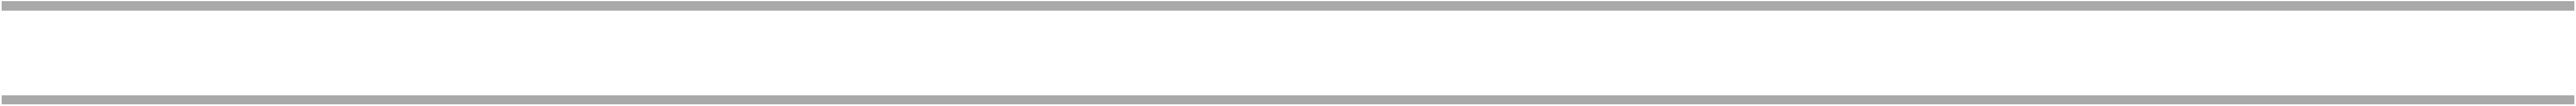

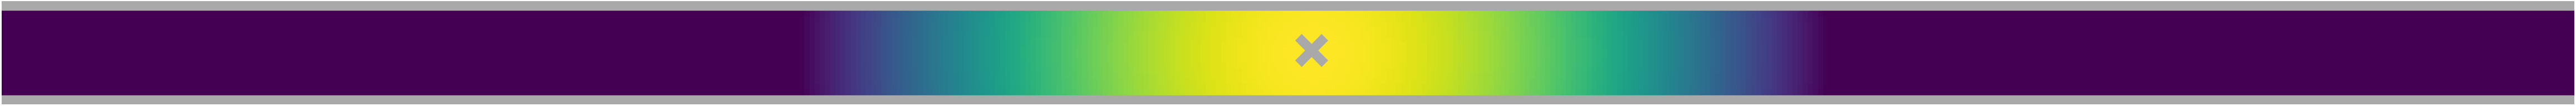

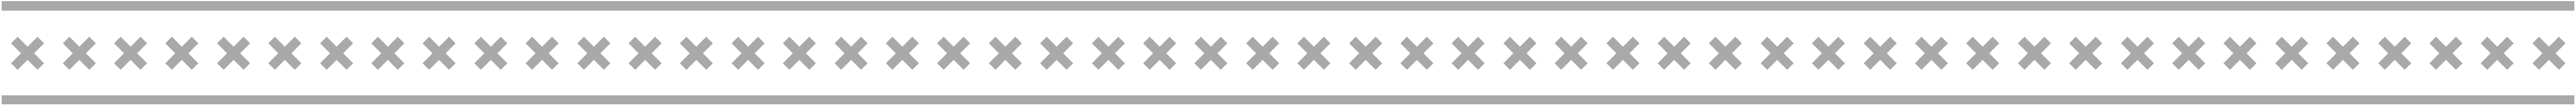

In [298]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.

# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 10,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      #pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #post trace decay time
          'a_STDP'              : -0.4,       #pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 5,          # von mises spread parameter
          
          #Theta scrambling params (Livi addition)
          'scramble_strength'    : 0.8,        # strength of theta phase scrambling 
          'hf_strength'          : 0.8,        # strength of high frequency jitter added to scrambled theta phase

}

agent_p = MazeAgent(params)
plotter = Visualiser(agent_p)
agent_p.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


### Simulation Loop and Plots

  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': "TD matrix 'M' after 30min of TD learning"}>,
 <Axes: >)

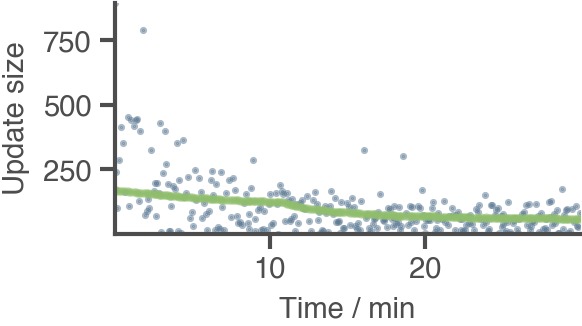

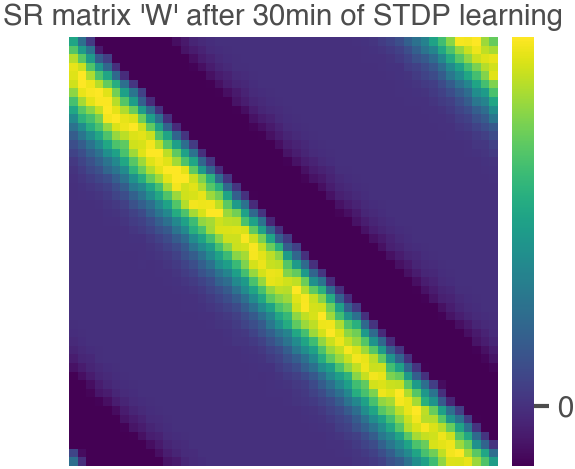

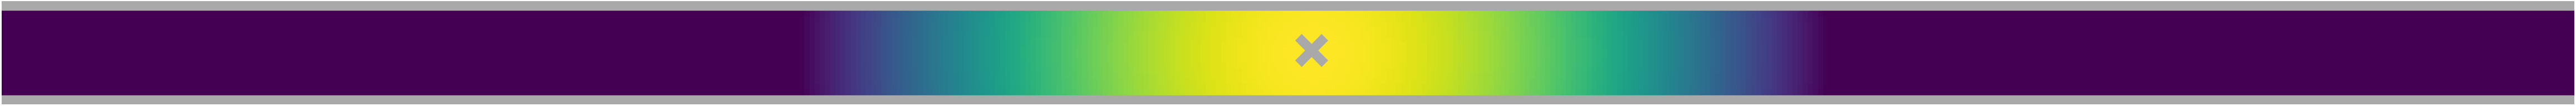

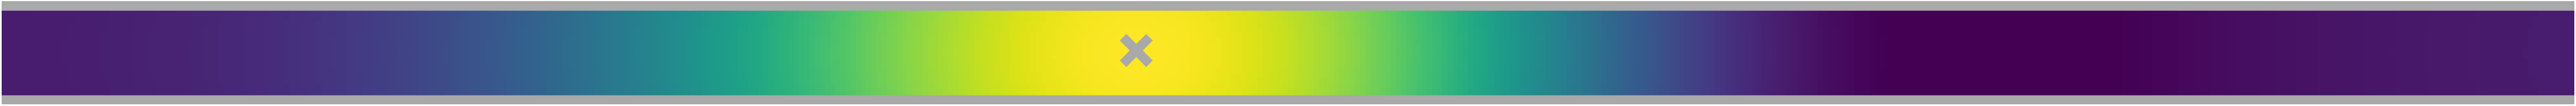

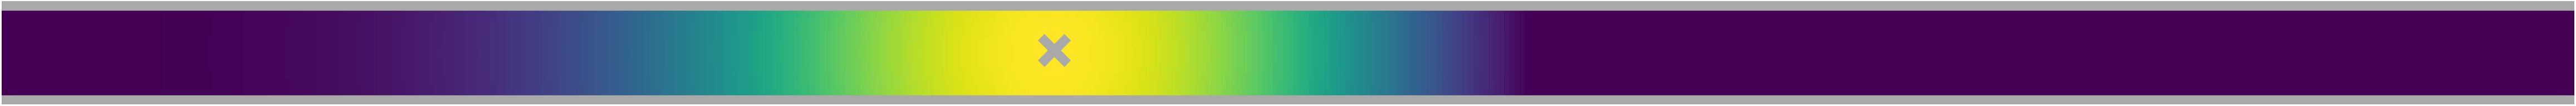

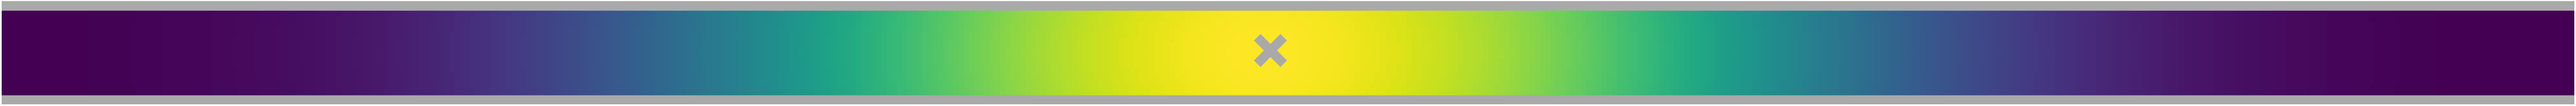

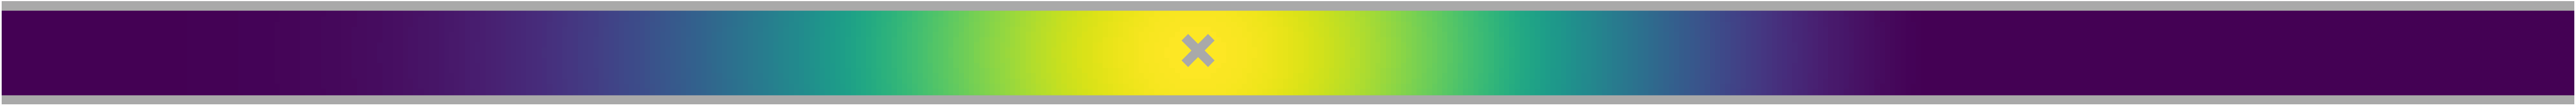

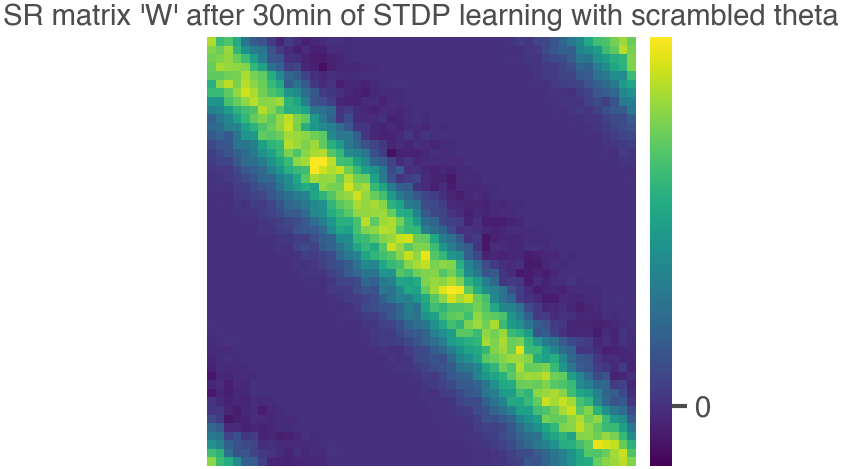

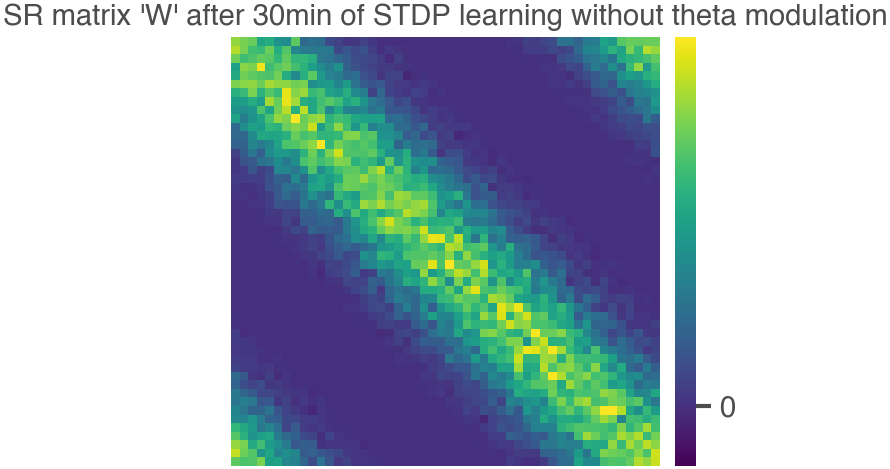

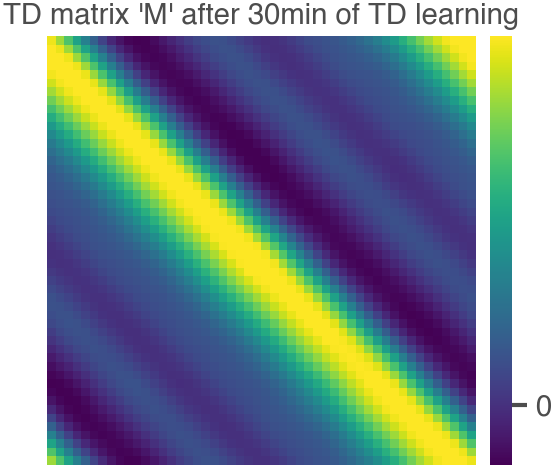

In [299]:
# Set parameters and run simulation
agent_p.pos = np.array([0,0.1])  
agent_p.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with STDP learning, no TD learning and save snapshots every 1min
model1= agent_p.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=0.5)
model1

# Define what to plot from this STDP run
plotter = Visualiser(agent_p) # create new plotter to access the data from the STDP run we just did

# PLOTTING
# plot STDP weight matrix 'W' with clean theta
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=True)
# plot basis feature again
plotter.plotReceptiveField(25)

# plot place field of cell 25 with TD learning 
fig, ax=plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=False, threshold=0.0)
#ax.set_title("Place field of cell 25 with TD learning", fontsize=12)

# plot place field of cell 25 with STDP learning (clean theta)
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, threshold=0.0)

# plot place field of cell 25 with STDP learning but no theta modulation 
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=True, threshold=0.0)

# scrambled that place field of cell 25 with STDP learning but no theta modulation
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False, scrambled=True, threshold=0.0)

# Plot scrambled
plotter.plotM(whichM="W_scrambled", colorbar=True, title="SR matrix 'W' after 30min of STDP learning with scrambled theta", save=True) 

# Plot no_theta
plotter.plotM(whichM="W_notheta", colorbar=True, title="SR matrix 'W' after 30min of STDP learning without theta modulation", save=True)

# Plot TD plots
plotter.plotM(whichM="M", colorbar=True, title="TD matrix 'M' after 30min of TD learning", save=True)


# Plot combined plots 
#plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True, return_data=True)
#plotter.plotMetrics(total_time=None, x_ticks=None)

## Plot Phase Precession for Clean and Scrambled Theta Condition
Theoretically one could also create the plot for the no theta condition, but there is no theta, meaning that in the bottom plot there is just a horizontal line instead of scattered points, bcs theta phase is on the y-axis but there is no phase in that condition. Hence, only Clean and scrambled theta will be plotted here.

Cell 15 fit stats: {'slope': np.float64(-1.5456478857049452), 'intercept': np.float64(6.001864986368201), 'r_value': np.float64(-0.8009252445772935), 'p_value': np.float64(0.0), 'std_err': np.float64(0.02091274865601234)}
Cell 20 fit stats: {'slope': np.float64(-1.5418011562075116), 'intercept': np.float64(6.780277512421002), 'r_value': np.float64(-0.8081006318708949), 'p_value': np.float64(0.0), 'std_err': np.float64(0.019992515928406018)}
Cell 25 fit stats: {'slope': np.float64(-1.5504754945473387), 'intercept': np.float64(7.553641764939613), 'r_value': np.float64(-0.8064455142720018), 'p_value': np.float64(0.0), 'std_err': np.float64(0.020615587690982606)}
Cell 30 fit stats: {'slope': np.float64(-1.5791823163083647), 'intercept': np.float64(8.43010261499155), 'r_value': np.float64(-0.8183029871899553), 'p_value': np.float64(0.0), 'std_err': np.float64(0.020326509561804366)}
Cell 35 fit stats: {'slope': np.float64(-1.5747025796156886), 'intercept': np.float64(9.210991243269808), 'r_v

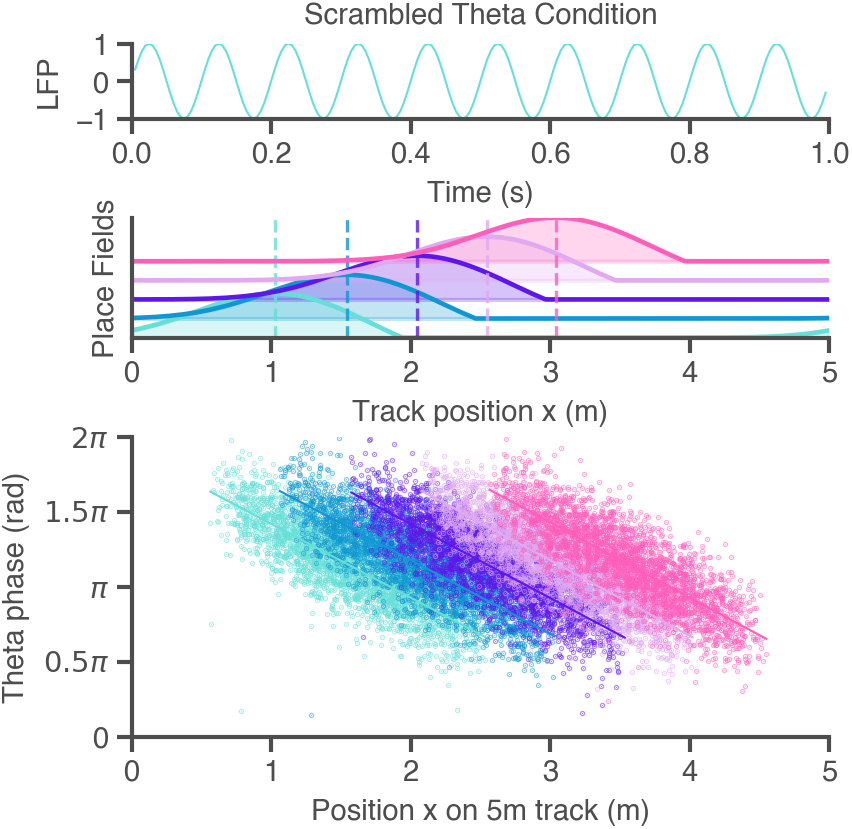

Cell 15 fit stats: {'slope': np.float64(-0.7488200254046479), 'intercept': np.float64(4.684916963098224), 'r_value': np.float64(-0.237809465664212), 'p_value': np.float64(1.5687880591611818e-41), 'std_err': np.float64(0.05465947479241229)}
Cell 20 fit stats: {'slope': np.float64(-0.7387020258473315), 'intercept': np.float64(5.010731401111508), 'r_value': np.float64(-0.2409530926301952), 'p_value': np.float64(7.960667278755862e-42), 'std_err': np.float64(0.053700655614167175)}
Cell 25 fit stats: {'slope': np.float64(-0.7421810446796566), 'intercept': np.float64(5.438914901703121), 'r_value': np.float64(-0.2356946886698259), 'p_value': np.float64(2.8660242452217347e-40), 'std_err': np.float64(0.055069412756421764)}
Cell 30 fit stats: {'slope': np.float64(-0.6782068327548938), 'intercept': np.float64(5.594351104066586), 'r_value': np.float64(-0.21921597425007458), 'p_value': np.float64(1.2333842239485554e-34), 'std_err': np.float64(0.054567622422465274)}
Cell 35 fit stats: {'slope': np.fl

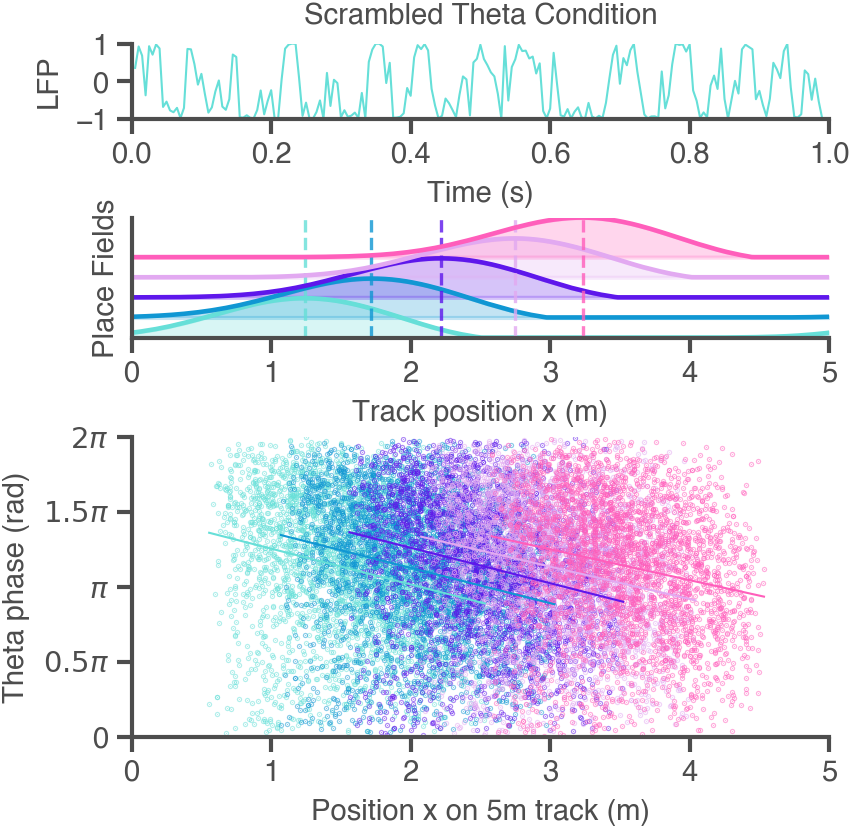

Intact theta condition R values: [np.float64(-0.8092939745092128), np.float64(-0.8092939745092128), np.float64(-0.8092939745092128), np.float64(-0.8092939745092128), np.float64(-0.8092939745092128)]
Scrambled theta condition R values: [np.float64(-0.20479115414370153), np.float64(-0.20479115414370153), np.float64(-0.20479115414370153), np.float64(-0.20479115414370153), np.float64(-0.20479115414370153)]
Dataframe of fit stats and learned centres for all cells and conditions:


In [296]:
# FUNCTION TO PLOT PHASE PRECESSION FOR DIFFERENT THETA CONDITIONS -> clean and scrambled
from matplotlib.font_manager import FontProperties
def plot_sequence_scatter(cond_key = "theta", phase_hist=None, agent=agent_p, selectedCells=None, save_name= None, fig= None, ax = None):
    """
    Plots three different plots stacked vertically:
    1. Top plot: LFP signal trace for a specific time window to show theta condition 
    2. Middle plot: the field silhouettes of the 5 selected cells for the selected theta condition
    3. Bottom plot: scatter plot of theta phase (0-2pi) vs position on the track for the spikes of the 5 selected cells 
    for a specific time window of the agent running in the 1D loop
    """
    plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

    # SELECT CELLS TO PLOT PLACE FIELDS FOR IN BOTTOM SCATTER PLOT and ABOVE
    if selectedCells is None or len(selectedCells) == 0:
        selected_cells = np.array([15, 20, 25, 30, 35], dtype=int)
    else:
        selected_cells = np.array(selectedCells, dtype=int)

    # define colors and labels for the 5 cells we will plot (A-E)
    colors = ['#66dfd8', "#1097d3", '#5e17eb', '#e2a9f1', '#ff5ebb']
    #colors = ["red", "gold", "green", "royalblue", "purple"]
    labels = ["A", "B", "C", "D", "E"]
    
    # Define subplot
    fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
        3, 1, figsize=(3,3), gridspec_kw={"height_ratios": [0.5, 0.8, 2]}, constrained_layout=False
    )
    fig.subplots_adjust(hspace=0.6, wspace=0.3)

    # VARIABLES BOTTOM PLOT
    # ----------------------
    # Set up the data for plotting
    t_history = agent.history["t"].to_numpy(dtype=float)
    pos_history = np.vstack(agent.history["pos"].to_numpy())  # shape (T,2)

    # VARIABLES TOP PLOT
    # ----------------------
    # clean theta phase: not stored as full history in this script -> reconstruct from time
    if phase_hist == "theta":
        thetaPhase_history = np.mod(2 * np.pi * agent.thetaFreq * t_history, 2*np.pi)
        phase_hist = thetaPhase_history # we will use this in the top plot to plot the LFP trace
    
    elif phase_hist == "notheta":
    # no theta modulation condition -> flat phase at pi/2 (peak of theta) to show that there is no modulation; adjust as needed if you want a different flat phase
        thetaPhase_notheta_history = np.full_like(t_history, np.pi/2) 
        phase_hist = thetaPhase_notheta_history # we will use this in the top plot to plot the LFP trace
    
    elif phase_hist == "scrambled":
    # scrambled phase history (stored during scrambled modulation)
        thetaPhase_scrambled_history = np.asarray(agent.thetaPhase_scrambled_history, dtype=float).reshape(-1)
        if thetaPhase_scrambled_history.ndim > 1: # .ndim means "number of dimensions" -> if it's more than 1D, we take the first column (assuming shape is (T,1))
            thetaPhase_scrambled_history = thetaPhase_scrambled_history[:, 0]
        thetaPhase_scrambled_history = np.mod(thetaPhase_scrambled_history, 2*np.pi) # np.mod ensures all phases are wrapped to [0, 2pi] bcs we want to plot them on a circular axis later
        phase_hist = thetaPhase_scrambled_history # we will use this in the top plot to plot the LFP trace

    # align lengths safely (because we have some time points where scrambled theta is not stored, so we take the min length across all histories to avoid indexing errors)
    n = min(len(t_history), len(pos_history), len(phase_hist))
    t_history = t_history[:n]
    pos_history = pos_history[:n]
    phase_hist = phase_hist[:n]

    # VARIABLES MIDDLE PLOT
    # ----------------------
    hist_id = agent.snapshots['t'].sub(30*60).abs().to_numpy().argmin()
    snapshot = agent.snapshots.iloc[hist_id-22]
     
    if cond_key == "theta":
        M_use = snapshot["W"]
    elif cond_key == "notheta":
        M_use = snapshot["W_notheta"]
    elif cond_key == "scrambled":
        M_use = snapshot["W_scrambled"]
    else:
        raise ValueError(f"Unknown cond_key: {cond_key}")   

    x = agent.discreteCoords[10,:,0]
    L = agent.roomSize
    pf_all = agent.getPlaceFields(M=M_use, threshold=0)

    learned_centres = {}
    for i, cell_id in enumerate(selected_cells):
        y = pf_all[cell_id, 10, :].copy()
        area = np.trapezoid(y, x)
        if area > 0:
            y = y / area

        # learned centre after learning (choose peak; robust and simple)
        mu_learned = x[np.argmax(y)]
        learned_centres[cell_id] = mu_learned

        y_off = i * 0.35
        ax_mid.fill_between(x, y_off, y + y_off, color=colors[i], alpha=0.25)
        ax_mid.plot(x, y + y_off, color=colors[i], lw=1.1, label=labels[i])
        ax_mid.axvline(mu_learned, color=colors[i], lw=0.8, ls="--", alpha=0.8)

    ax_mid.set_xlim(0, L)
    ax_mid.set_xlabel("Track position x (m)")
    ax_mid.set_ylabel("Place Fields")
    #ax_mid.set_title("Place Fields and Centres of Selected CA1 Cells After Learning", fontweight='bold', y=1.1)
    ax_mid.set_yticks([])
    ax_mid.spines["top"].set_visible(False)
    ax_mid.spines["right"].set_visible(False)
    
    # ---------------------
    # CREATE MASKS FOR DIFFERENT TIME WINDOWS

    # SETTNGS FOR MASK FOR BOTTOM PLOT
    t_start_b, t_end_b = 500.0, 3600.0
    mask_t_b = (t_history >= t_start_b) & (t_history <= t_end_b)
    t_win_b = t_history[mask_t_b]
    x_win_b = pos_history[mask_t_b, 0] # 0 is x-coordinate; we will plot phase vs x-position, so we only need the x-coordinate here

    # SETTINGS MASK MIDDLE PLOT
    t_start_m, t_end_m = 0.0, 30.0
    mask_t_m = (t_history >= t_start_m) & (t_history <= t_end_m)
    t_win_m = t_history[mask_t_m]
    x_win_m = pos_history[mask_t_m, 0]

    # SETTINGS MASK LFP PLOT
    t_start_lfp, t_end_lfp = 0.0, 1.0
    mask_t_lfp = (t_history >= t_start_lfp) & (t_history <= t_end_lfp)
    t_win_lfp = t_history[mask_t_lfp]
    x_win_lfp = pos_history[mask_t_lfp, 0]


    # TOP PLOT: LFP
    lfp = np.sin(phase_hist[mask_t_lfp])
    ax_top.plot(t_win_lfp, lfp, color="#66dfd8")

    ax_top.set_xlim(t_start_lfp, t_end_lfp)
    ax_top.set_ylim(-1.0, 1.0)
    ax_top.set_ylabel("LFP")
    ax_top.set_xlabel("Time (s)")
    ax_top.set_title("Scrambled Theta Condition", fontweight='bold', y= 1.1)
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # BOTTOM PLOT: phase-position scatter (main plot)
    sp = agent.spikedata_by_condition[cond_key]["CA1"] # get spike data for this condition and CA3 cells; adjust key if your data structure is different
    spike_times_all = np.asarray(sp["times"], dtype=float) # get all spike times for this condition and CA1 cells; adjust key if your data structure is different
    spike_ids_all = np.asarray(sp["ids"], dtype=int) # get all spike cell IDs for this condition and CA1 cells; adjust key if your data structure is different

    for i, cell_id in enumerate(selected_cells):
        cell_mask = (spike_ids_all == cell_id) # boolean mask to select spikes from this cell
        st = spike_times_all[cell_mask] # spike times for this cell
        st = st[(st >= t_start_b) & (st <= t_end_b)] # further mask to select spikes within the time window; adjust t_start and t_end as needed
        if st.size == 0: # if there are no spikes for this cell in the time window, skip to avoid errors in interpolation
            continue
        
        # interpolate position and phase at spike times; np.interp will give us the position and phase at the exact spike times based on the recorded history, which we can then plot in the scatter plot
        pos_at_spike = np.interp(st, t_history, pos_history[:, 0]) # position (x-coordinate) at spike times
        phase_at_spike = np.mod(np.interp(st, t_history, phase_hist), 2*np.pi) # phase at spike times, wrapped to [0, 2pi] for circular plotting

        # plot spikes for this cell in the scatter plot with the corresponding color and label
        ax_bot.scatter(pos_at_spike, phase_at_spike, c=colors[i], s=0.08, alpha=0.5, label=labels[i])

        # ADD REGRESSION LINE (# to remove)
        if len(pos_at_spike) > 1:  # need at least 2 points
            slope, intercept, r_value, p_value, std_err = stats.linregress(pos_at_spike, phase_at_spike)
            x_line = np.linspace(pos_at_spike.min(), pos_at_spike.max(), 100)
            y_line = slope * x_line + intercept
            ax_bot.plot(x_line, y_line, color=colors[i], linestyle='-', alpha=1.0, linewidth=0.5)
            # compute fit statistics including R2 of the fit line
            fit_stats = {
                'slope': slope,
                'intercept': intercept,
                'r_value': r_value,
                'p_value': p_value,
                'std_err': std_err
            }
            print(f"Cell {cell_id} fit stats: {fit_stats}") # print fit stats for this cell

    ax_bot.set_xlabel("Position x on 5m track (m)")
    ax_bot.set_ylabel("Theta phase (rad)")
    #ax_bot.set_title("Spikes of CA1 Cells at Position x(t) Relative to Theta Phase", fontweight='bold', y=1.04)
    ax_bot.set_ylim(0, 2*np.pi)
    ax_bot.set_xlim(0, 5.0)
    ax_bot.set_yticks([0, 0.5* np.pi, np.pi, 1.5* np.pi, 2*np.pi])
    ax_bot.set_yticklabels(["0", r"$0.5\pi$", r"$\pi$", r"$1.5\pi$", r"$2\pi$"])
    ax_bot.spines["top"].set_visible(False)
    ax_bot.spines["right"].set_visible(False)

    # add font family in bold and title for whole figure
    title_font = FontProperties(family="Arial", weight="bold") # you can change the font family as needed; "DejaVu Sans" is a common one that should be available in most matplotlib installations
    #plt.suptitle(f'Theta Trace, Place Fields & Spike Precession across Run for Intact Theta (kappa=10)', y=0.95, fontproperties=title_font) # you can change the font family as needed; "DejaVu Sans" is a common one that should be available in most matplotlib installations

    #plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PrecessionScrambledBioPlausibleLiviPalette.png", transparent=True)
    #fig.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    return learned_centres, fit_stats

#plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')
# theta
learnedCentres, fitStats_intact = plot_sequence_scatter(cond_key = "theta", phase_hist= "theta", agent=agent_p, selectedCells=[15, 20, 25, 30, 35], save_name= None, fig= None, ax = None)
# save figure
#plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PrecessionIntact10KLiviPalette.pdf", transparent=True)
# scrambled (key is 'scrambled' in your code)
learnedCentres_06scrambled, fitStats_06scrambled = plot_sequence_scatter(cond_key = "scrambled", phase_hist= "scrambled", agent=agent_p, selectedCells=None, save_name= None, fig= None, ax = None)
# no theta modulation but doesn't really make sense to plot bcs there is no theta phase
# plot_sequence_scatter(cond_key = "notheta", phase_hist= "notheta", agent=agent_p, selectedCells=None, save_name= None, fig= None, ax = None)

# create one dataframe in which to store fit stats and learned centres for all cells in the population separated by theta condition, so we can analyse them later and plot distributions etc.
#df_fit_stats = pd.DataFrame({
    #'cell_id': list(learnedCentres.keys()) + list(learnedCentres_04scrambled.keys()),
    #'learned_centre': list(learnedCentres.values()) + list(learnedCentres_04scrambled.values()),
    #'slope': [fitStats_intact['slope']] * len(learnedCentres) + [fitStats_04scrambled['slope']] * len(learnedCentres_04scrambled),
    #'intercept': [fitStats_intact['intercept']] * len(learnedCentres) + [fitStats_04scrambled['intercept']] * len(learnedCentres_04scrambled),
    #'r_value': [fitStats_intact['r_value']] * len(learnedCentres) + [fitStats_04scrambled['r_value']] * len(learnedCentres_04scrambled),
    #'p_value': [fitStats_intact['p_value']] * len(learnedCentres) + [fitStats_04scrambled['p_value']] * len(learnedCentres_04scrambled),
    #'std_err': [fitStats_intact['std_err']] * len(learnedCentres) + [fitStats_04scrambled['std_err']] * len(learnedCentres_04scrambled),
    #'condition': ['intact'] * len(learnedCentres) + ['scrambled'] * len(learnedCentres_04scrambled) # add a column to indicate the condition for each row

#})

# print r_values for cell for intact and scrambled conditions
print("Intact theta condition R values:", [fitStats_intact['r_value']] * len(learnedCentres))
print("Scrambled theta condition R values:", [fitStats_06scrambled['r_value']] * len(learnedCentres_06scrambled))
print("Dataframe of fit stats and learned centres for all cells and conditions:")
#print(df_fit_stats)

# append new scrambled condition to dataframe
new_rows = pd.DataFrame({
    'cell_id': list(learnedCentres_06scrambled.keys()),#    'learned_centre': list(learnedCentres_04scrambled.values()),
    'slope': [fitStats_06scrambled['slope']] * len(learnedCentres_06scrambled),
    'intercept': [fitStats_06scrambled['intercept']] * len(learnedCentres_06scrambled),
    'r_value': [fitStats_06scrambled['r_value']] * len(learnedCentres_06scrambled),
    'p_value': [fitStats_06scrambled['p_value']] * len(learnedCentres_06scrambled),
    'std_err': [fitStats_06scrambled['std_err']] * len(learnedCentres_06scrambled),
    'condition': ['scrambled_06'] * len(learnedCentres_06scrambled) # add a column to indicate the condition for each row
})  

# append with concat to df_fit_stats
df_fit_stats = pd.concat([df_fit_stats, new_rows], ignore_index=True)


In [297]:
print(df_fit_stats)
# remove the rows for the scrambled condition with 0.4 strength if they exist, because we are only keeping the 0.6 scrambled condition now
#df_fit_stats = df_fit_stats[df_fit_stats['condition'] != 'scrambled']

   cell_id  learned_centre     slope  intercept   r_value       p_value  \
0       15           1.045 -1.571605   9.191413 -0.815290  0.000000e+00   
1       20           1.545 -1.571605   9.191413 -0.815290  0.000000e+00   
2       25           2.035 -1.571605   9.191413 -0.815290  0.000000e+00   
3       30           2.545 -1.571605   9.191413 -0.815290  0.000000e+00   
4       35           3.045 -1.571605   9.191413 -0.815290  0.000000e+00   
5       15             NaN -0.647517   5.866197 -0.204791  9.874070e-30   
6       20             NaN -0.647517   5.866197 -0.204791  9.874070e-30   
7       25             NaN -0.647517   5.866197 -0.204791  9.874070e-30   
8       30             NaN -0.647517   5.866197 -0.204791  9.874070e-30   
9       35             NaN -0.647517   5.866197 -0.204791  9.874070e-30   

    std_err     condition  
0  0.020339        intact  
1  0.020339        intact  
2  0.020339        intact  
3  0.020339        intact  
4  0.020339        intact  
5  0.0

### Individual plot parts of precession plot

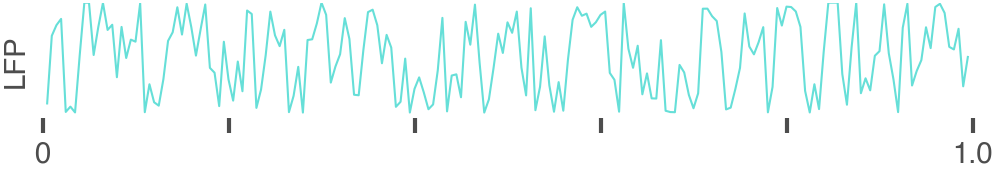

In [265]:
# TOP PLOT: LFP (INTACT OR SCRAMBLED)
plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

fig, ax = plt.subplots(figsize=(4,0.5))

phase_hist = "scrambled"
# define agent to access history data from the STDP run we just did
agent = agent_p

# Set up the data for plotting
t_history = agent.history["t"].to_numpy(dtype=float)
pos_history = np.vstack(agent.history["pos"].to_numpy())  # shape (T,2)

# clean theta phase: not stored as full history in this script -> reconstruct from time
if phase_hist == "theta":
    thetaPhase_history = np.mod(2 * np.pi * agent.thetaFreq * t_history, 2*np.pi)
    phase_hist = thetaPhase_history # we will use this in the top plot to plot the LFP trace
    
elif phase_hist == "notheta":
# no theta modulation condition -> flat phase at pi/2 (peak of theta) to show that there is no modulation; adjust as needed if you want a different flat phase
    thetaPhase_notheta_history = np.full_like(agent.t_history, np.pi/2) 
    phase_hist = thetaPhase_notheta_history # we will use this in the top plot to plot the LFP trace
    
elif phase_hist == "scrambled":
# scrambled phase history (stored during scrambled modulation)
    thetaPhase_scrambled_history = np.asarray(agent.thetaPhase_scrambled_history, dtype=float).reshape(-1)
    if thetaPhase_scrambled_history.ndim > 1: # .ndim means "number of dimensions" -> if it's more than 1D, we take the first column (assuming shape is (T,1))
        thetaPhase_scrambled_history = thetaPhase_scrambled_history[:, 0]
    thetaPhase_scrambled_history = np.mod(thetaPhase_scrambled_history, 2*np.pi) # np.mod ensures all phases are wrapped to [0, 2pi] bcs we want to plot them on a circular axis later
    phase_hist = thetaPhase_scrambled_history # we will use this in the top plot to plot the LFP trace

# align lengths safely (because we have some time points where scrambled theta is not stored, so we take the min length across all histories to avoid indexing errors)
n = min(len(t_history), len(pos_history), len(phase_hist))
t_history = t_history[:n]
pos_history = pos_history[:n]
phase_hist = phase_hist[:n]

# SETTINGS MASK LFP PLOT
t_start_lfp, t_end_lfp = 0.0, 1.0
mask_t_lfp = (t_history >= t_start_lfp) & (t_history <= t_end_lfp)
t_win_lfp = t_history[mask_t_lfp]
x_win_lfp = pos_history[mask_t_lfp, 0]

# TOP PLOT: LFP
lfp = np.sin(phase_hist[mask_t_lfp])
ax.plot(t_win_lfp, lfp, color="#66dfd8")

ax.set_xlim(t_start_lfp, t_end_lfp)
ax.set_ylim(-1.1, 1.0)
ax.set_ylabel("LFP")
#ax.set_xlabel("Time (s)")
#ax.set_title("Scrambled Theta Condition", fontweight='bold', y= 1.1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(["0", "", "", "", "", "1.0"])

plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/LFPScrambled5KLong.pdf", transparent=True)

plt.show()

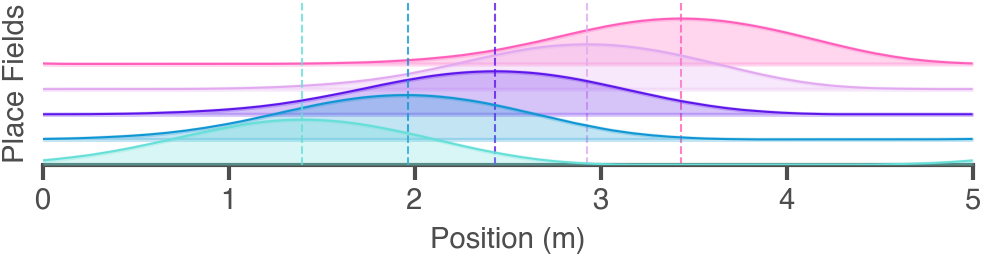

In [268]:
# MIDDLE PLOT: PLACE FIELDS
plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

fig, ax = plt.subplots(figsize=(4,0.7))

phase_hist = "scrambled"
cond_key = "scrambled"
selected_cells = np.array([15, 20, 25, 30, 35], dtype=int)
colors = ['#66dfd8', "#1097d3", '#5e17eb', '#e2a9f1', '#ff5ebb']
labels = ["A", "B", "C", "D", "E"]
# define agent to access history data from the STDP run we just did
agent = agent_p

# Set up the data for plotting
t_history = agent.history["t"].to_numpy(dtype=float)
pos_history = np.vstack(agent.history["pos"].to_numpy())  # shape (T,2)

# VARIABLES MIDDLE PLOT
# # ----------------------
hist_id = agent.snapshots['t'].sub(30*60).abs().to_numpy().argmin()
snapshot = agent.snapshots.iloc[hist_id-22]
     
if cond_key == "theta":
    M_use = snapshot["W"]
elif cond_key == "notheta":
    M_use = snapshot["W_notheta"]
elif cond_key == "scrambled":
    M_use = snapshot["W_scrambled"]
else:
    raise ValueError(f"Unknown cond_key: {cond_key}")   

x = agent.discreteCoords[10,:,0]
L = agent.roomSize
pf_all = agent.getPlaceFields(M=M_use, threshold=0)

learned_centres = {}
for i, cell_id in enumerate(selected_cells):
    y = pf_all[cell_id, 10, :].copy()
    area = np.trapezoid(y, x)
    if area > 0:
        y = y / area

    # learned centre after learning (choose peak; robust and simple)
    mu_learned = x[np.argmax(y)]
    learned_centres[cell_id] = mu_learned

    y_off = i * 0.35
    z = len(selected_cells) - i
    ax.fill_between(x, y_off, y + y_off, color=colors[i], alpha=0.25, zorder=z)
    ax.plot(x, y + y_off, color=colors[i], label=labels[i], zorder=z+0.1)
    ax.axvline(mu_learned, color=colors[i], ls="--", alpha=0.8, zorder=z+0.2)

ax.set_xlim(0, L)
ax.set_ylim(0, y_off + 0.85)
ax.set_xlabel("Position (m)")
ax.set_ylabel("Place Fields",)
#ax.set_title("Place Fields and Centres of Selected CA1 Cells After Learning", fontweight='bold', y=1.1)
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# SETTINGS MASK MIDDLE PLOT
t_start_m, t_end_m = 0.0, 30.0
mask_t_m = (t_history >= t_start_m) & (t_history <= t_end_m)
t_win_m = t_history[mask_t_m]
x_win_m = pos_history[mask_t_m, 0]

plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PlaceFieldsScrambled5KLong.pdf", transparent=True)

plt.show()

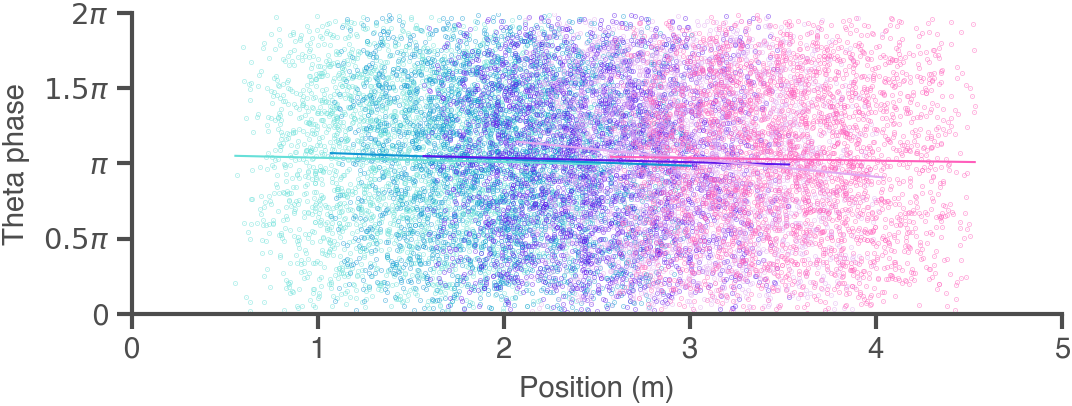

In [269]:
# BOTTOM PLOT: PHASE-POSITION SCATTER
plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

fig, ax = plt.subplots(figsize=(4,1.3))

phase_hist = "scrambled"
cond_key = "scrambled"
selected_cells = np.array([15, 20, 25, 30, 35], dtype=int)
colors = ['#66dfd8', "#1097d3", '#5e17eb', '#e2a9f1', '#ff5ebb']
labels = ["A", "B", "C", "D", "E"]
# define agent to access history data from the STDP run we just did
agent = agent_p

# Set up the data for plotting
t_history = agent.history["t"].to_numpy(dtype=float)
pos_history = np.vstack(agent.history["pos"].to_numpy())  # shape (T,2)

# clean theta phase: not stored as full history in this script -> reconstruct from time
if phase_hist == "theta":
    thetaPhase_history = np.mod(2 * np.pi * agent.thetaFreq * t_history, 2*np.pi)
    phase_hist = thetaPhase_history # we will use this in the top plot to plot the LFP trace
    
elif phase_hist == "notheta":
# no theta modulation condition -> flat phase at pi/2 (peak of theta) to show that there is no modulation; adjust as needed if you want a different flat phase
    thetaPhase_notheta_history = np.full_like(t_history, np.pi/2) 
    phase_hist = thetaPhase_notheta_history # we will use this in the top plot to plot the LFP trace
    
elif phase_hist == "scrambled":
# scrambled phase history (stored during scrambled modulation)
    thetaPhase_scrambled_history = np.asarray(agent.thetaPhase_scrambled_history, dtype=float).reshape(-1)
    if thetaPhase_scrambled_history.ndim > 1: # .ndim means "number of dimensions" -> if it's more than 1D, we take the first column (assuming shape is (T,1))
        thetaPhase_scrambled_history = thetaPhase_scrambled_history[:, 0]
    thetaPhase_scrambled_history = np.mod(thetaPhase_scrambled_history, 2*np.pi) # np.mod ensures all phases are wrapped to [0, 2pi] bcs we want to plot them on a circular axis later
    phase_hist = thetaPhase_scrambled_history # we will use this in the top plot to plot the LFP trace

# align lengths safely (because we have some time points where scrambled theta is not stored, so we take the min length across all histories to avoid indexing errors)
n = min(len(t_history), len(pos_history), len(phase_hist))
t_history = t_history[:n]
pos_history = pos_history[:n]
phase_hist = phase_hist[:n]

# SETTNGS FOR MASK FOR BOTTOM PLOT
t_start_b, t_end_b = 500.0, 3600.0
mask_t_b = (t_history >= t_start_b) & (t_history <= t_end_b)
t_win_b = t_history[mask_t_b]
x_win_b = pos_history[mask_t_b, 0] # 0 is x-coordinate; we will plot phase vs x-position, so we only need the x-coordinate here

# BOTTOM PLOT: phase-position scatter (main plot)
sp = agent.spikedata_by_condition[cond_key]["CA1"] # get spike data for this condition and CA3 cells; adjust key if your data structure is different
spike_times_all = np.asarray(sp["times"], dtype=float) # get all spike times for this condition and CA1 cells; adjust key if your data structure is different
spike_ids_all = np.asarray(sp["ids"], dtype=int) # get all spike cell IDs for this condition and CA1 cells; adjust key if your data structure is different

for i, cell_id in enumerate(selected_cells):
    cell_mask = (spike_ids_all == cell_id) # boolean mask to select spikes from this cell
    st = spike_times_all[cell_mask] # spike times for this cell
    st = st[(st >= t_start_b) & (st <= t_end_b)] # further mask to select spikes within the time window; adjust t_start and t_end as needed
    if st.size == 0: # if there are no spikes for this cell in the time window, skip to avoid errors in interpolation
        continue
        
    # interpolate position and phase at spike times; np.interp will give us the position and phase at the exact spike times based on the recorded history, which we can then plot in the scatter plot
    pos_at_spike = np.interp(st, t_history, pos_history[:, 0]) # position (x-coordinate) at spike times
    phase_at_spike = np.mod(np.interp(st, t_history, phase_hist), 2*np.pi) # phase at spike times, wrapped to [0, 2pi] for circular plotting

    # plot spikes for this cell in the scatter plot with the corresponding color and label
    ax.scatter(pos_at_spike, phase_at_spike, c=colors[i], s=0.04, alpha=0.5, label=labels[i])

    # ADD REGRESSION LINE (# to remove)
    if len(pos_at_spike) > 1:  # need at least 2 points
        slope, intercept, r_value, p_value, std_err = stats.linregress(pos_at_spike, phase_at_spike)
        x_line = np.linspace(pos_at_spike.min(), pos_at_spike.max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=colors[i], linestyle='-', alpha=1.0, linewidth=0.5)

ax.set_xlabel("Position (m)")
ax.set_ylabel("Theta phase")
#ax.set_title("Spikes of CA1 Cells at Position x(t) Relative to Theta Phase", fontweight='bold', y=1.04)
ax.set_ylim(0, 2*np.pi)
ax.set_xlim(0, 5.0)
ax.set_yticks([0, 0.5* np.pi, np.pi, 1.5* np.pi, 2*np.pi])
ax.set_yticklabels(["0", r"$0.5\pi$", r"$\pi$", r"$1.5\pi$", r"$2\pi$"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/PrecessionScatterScrambled5KLong.pdf", transparent=True)

plt.show()

R2: M-->W= 0.8300207637265815 M-->Wnotheta= 0.6937851544232341 M-->Wscrambled= 0.8638246430428976
R2: M-->W= 0.8300207637265815 M-->Wnotheta= 0.6937851544232341 M-->Wscrambled= 0.8638246430428976
R2: M-->W= 0.8300207637265815 M-->Wnotheta= 0.6937851544232341 M-->Wscrambled= 0.8638246430428976
R2: M-->W= 0.8300207637265815 M-->Wnotheta= 0.6937851544232341 M-->Wscrambled= 0.8638246430428976
R2: M-->W= 0.8300207637265815 M-->Wnotheta= 0.6937851544232341 M-->Wscrambled= 0.8638246430428976


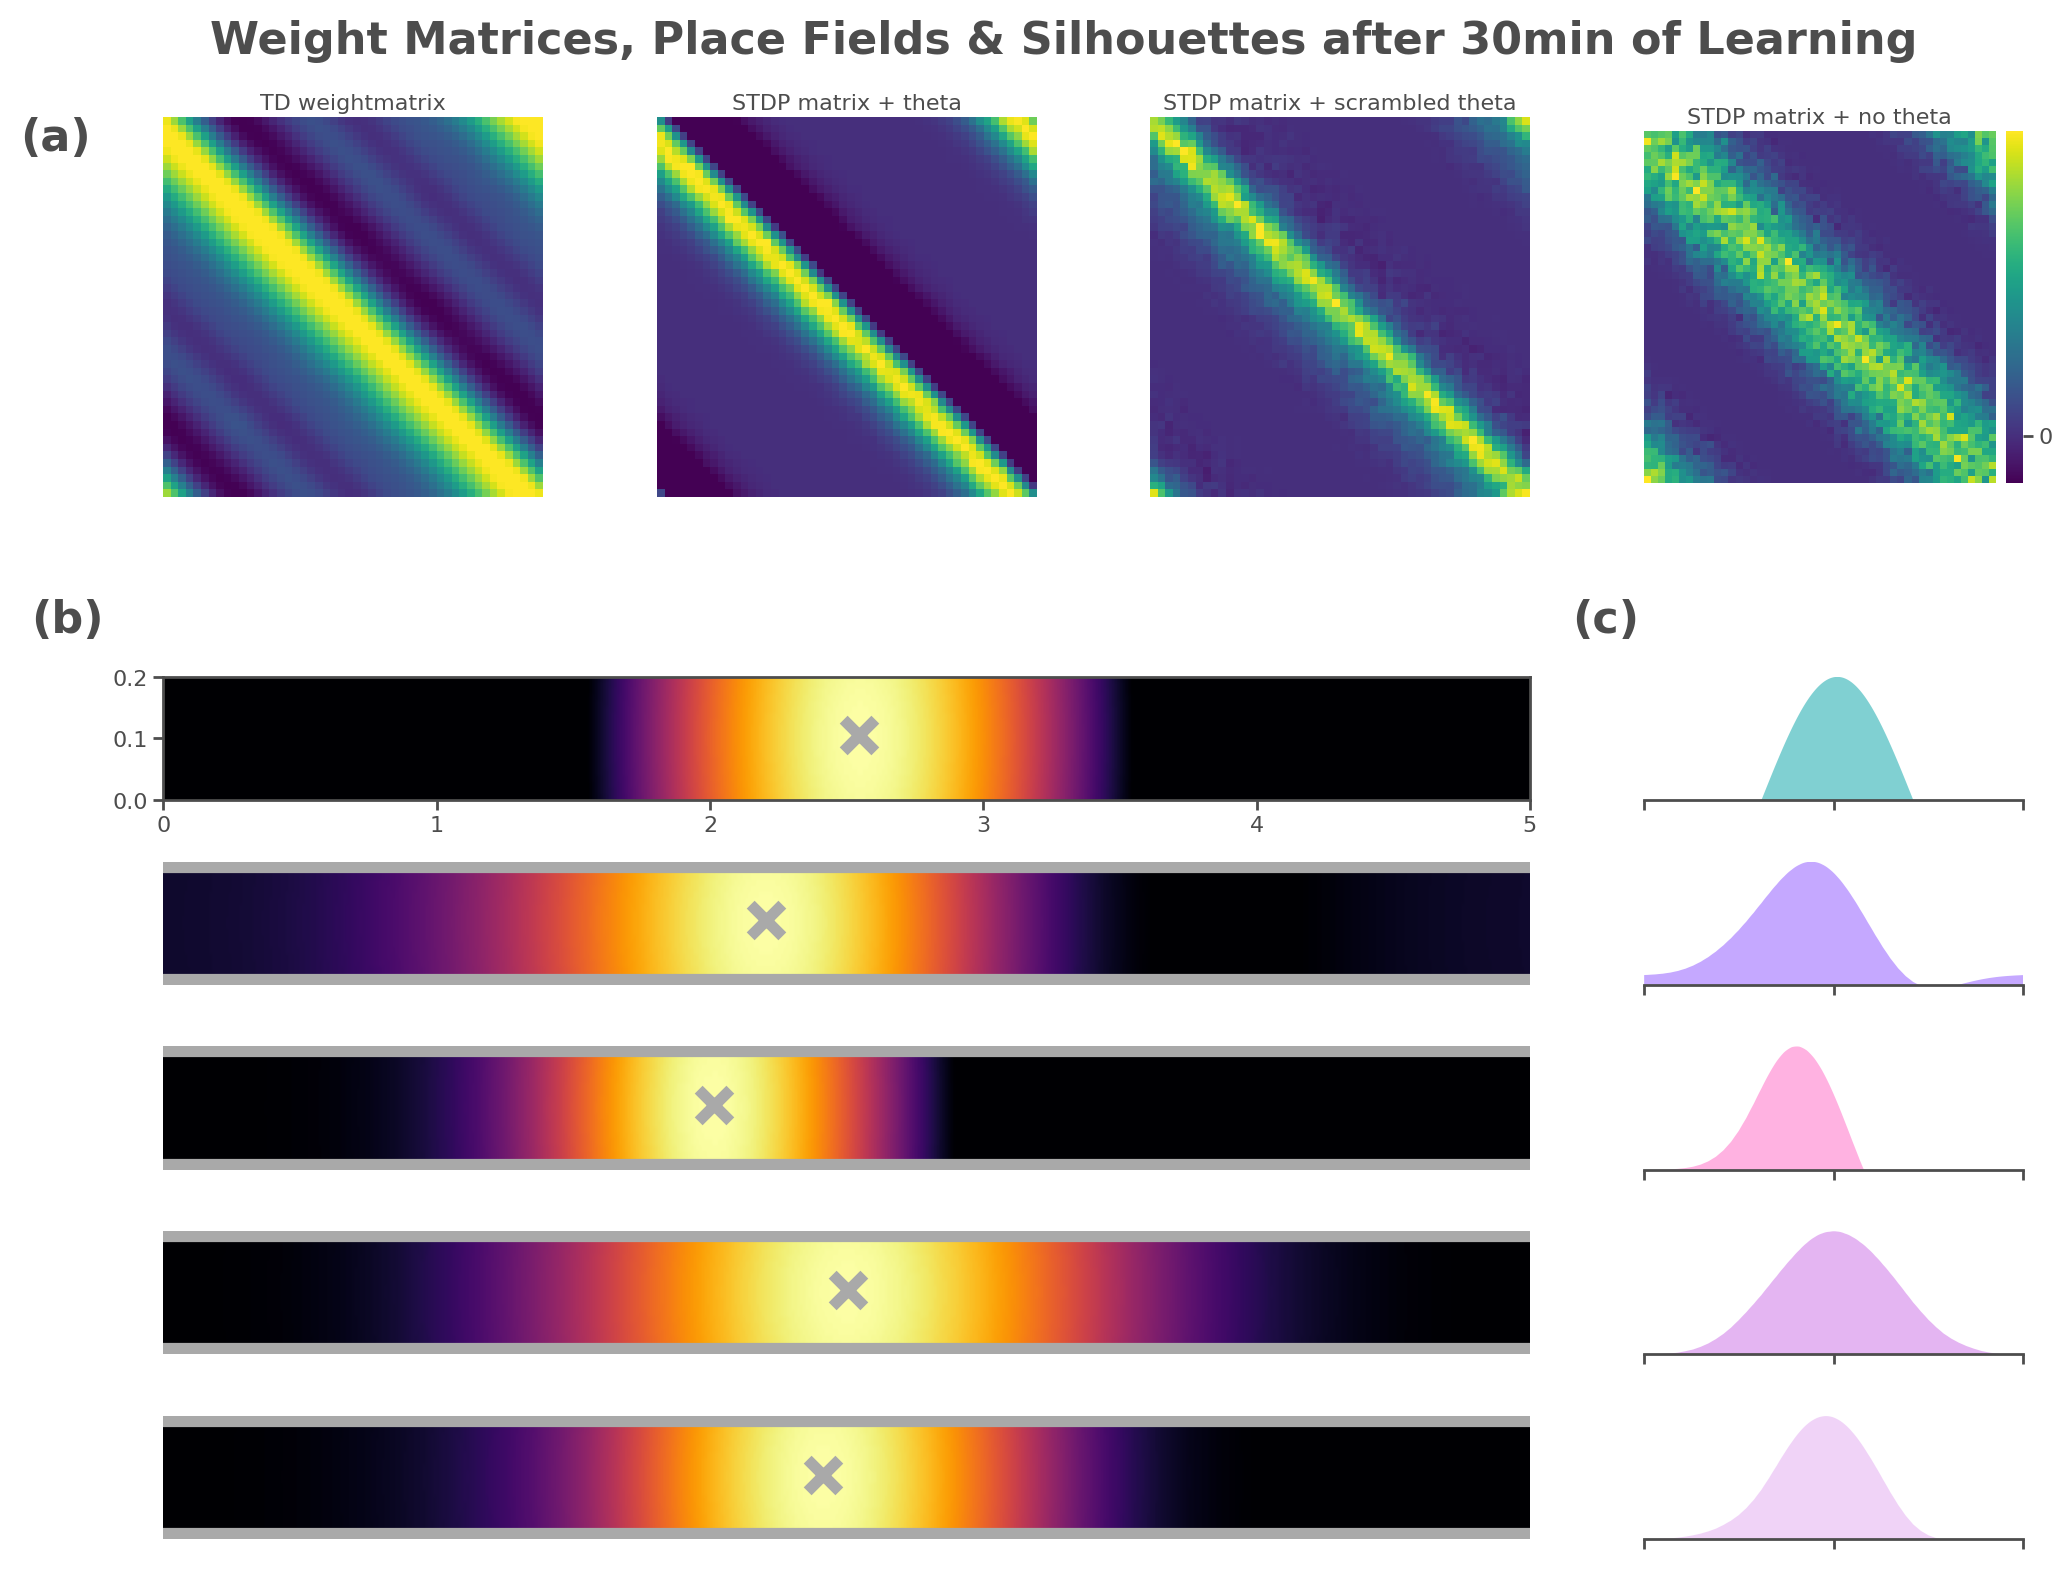

In [76]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(12, 10), constrained_layout=False)
gs = gridspec.GridSpec(6, 4, height_ratios=[2, 0.4, 0.4, 0.4, 0.4, 0.4], hspace=0.3, wspace=0.3)

# Top row: 4 square plots (row 0, columns 0-3)
ax1 = fig.add_subplot(gs[0, 0])  # Square 1
plotter.plotM(whichM="M", colorbar=False, title="TD weightmatrix", save=False, plotTimeStamp=False, fig=fig, ax=ax1)
ax2 = fig.add_subplot(gs[0, 1])  # Square 2
plotter.plotM(whichM="W", colorbar=False, title="STDP matrix + theta", save=False, fig=fig, ax=ax2)
ax3 = fig.add_subplot(gs[0, 2])  # Square 3
plotter.plotM(whichM="W_scrambled", colorbar=False, title="STDP matrix + scrambled theta", save=False, fig=fig, ax=ax3)
ax4 = fig.add_subplot(gs[0, 3])  # Square 4
plotter.plotM(whichM="W_notheta", colorbar=True, title="STDP matrix + no theta", save=False, fig=fig, ax=ax4)

# 5 wide/narrow plots below (rows 1-5, columns 0-1; twice as wide)
ax5 = fig.add_subplot(gs[1, 0:3])
plotter.plotReceptiveField(25, fig=fig, ax=ax5)
ax5.set_aspect('auto') 
ax6 = fig.add_subplot(gs[2, 0:3]) #TD place field
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=False, threshold=0.0, fig=fig, ax=ax6)
ax6.set_aspect('auto')
ax7 = fig.add_subplot(gs[3, 0:3]) # STDP place field with theta
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=True, no_theta=False, threshold=0.0, fig=fig, ax=ax7)
ax7.set_aspect('auto')
ax8 = fig.add_subplot(gs[4, 0:3]) # STDP place field without theta
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=True, no_theta=True, threshold=0.0, fig=fig, ax=ax8)
ax8.set_aspect('auto')
ax9 = fig.add_subplot(gs[5, 0:3]) # STDP place field with scrambled theta
plotter.plotPlaceField(hist_id=-1, number=25, save=False, STDP=True, no_theta=False, scrambled=True, threshold=0.0, fig=fig, ax=ax9)
ax9.set_aspect('auto')

# 5 shorter plots to the right (rows 1-5, column 2 only; half as wide)
ax10 = fig.add_subplot(gs[1, 3]) # RF before learning
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=False, plot_pf_M=False, plot_rf=True, plot_pf_scrambled=False, no_theta=False, ax=ax10)
ax11 = fig.add_subplot(gs[2, 3]) # RF after TD learning
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=False, plot_pf_M=True, plot_rf=False, plot_pf_scrambled=False, no_theta=False, ax=ax11)
ax12 = fig.add_subplot(gs[3, 3]) # RF after STDP learning with theta
plotter.plotFieldSilhouette(N=25, plot_pf=True, plot_pf_notheta=False, plot_pf_M=False, plot_rf=False, plot_pf_scrambled=False, no_theta=False, ax=ax12) # STDP with theta
ax13 = fig.add_subplot(gs[4, 3]) # RF after STDP learning without theta
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=True, plot_pf_M=False, plot_rf=False, plot_pf_scrambled=False, no_theta=False, ax=ax13) # STDP without theta
ax14 = fig.add_subplot(gs[5, 3]) # RF after STDP learning with scrambled theta
plotter.plotFieldSilhouette(N=25, plot_pf=False, plot_pf_notheta=False, plot_pf_M=False, plot_rf=False, plot_pf_scrambled=True, no_theta=False, ax=ax14) # STDP with scrambled theta

# add labels
labels = ['(a)', '(b)', '(c)']
fig.suptitle('Weight Matrices, Place Fields & Silhouettes after 30min of Learning', fontsize=16, fontweight='bold', y=0.87)
# (a) - Above top row (center)
fig.text(0.08, 0.80, labels[0], fontsize=16, fontweight='bold', 
         ha='center', va='bottom', transform=fig.transFigure)

# (b) - Left of bottom-left wide plots
fig.text(0.1, 0.57, labels[1], fontsize=16, fontweight='bold', 
         ha='right', va='center', transform=fig.transFigure)

# (c) - Left of bottom-right narrow plots  
fig.text(0.74, 0.57, labels[2], fontsize=16, fontweight='bold',
         ha='right', va='center', transform=fig.transFigure)

plt.show()

## Second Plot: Individual Spikes Relative to Theta Phase in a Specific Time Window

This second plot does however not show clear theta sequences in the specific time bins for each theta cycle. In their paper, George et al. (2023) state that "In our model phase, precession generates theta sweeps (Figure 1a, grey box) as cells successively visited along the current trajectory fire at progressively later times in each theta cycle. Theta sweeps take the current trajectory of the agent and effectively compress it in time. As we show below these compressed trajectories are important for learning successor features." In theory this i plausible, since in their model phase precession means that the preferred phase of a cell moves to earlier and earlier phases of the global theta oscillation as the agent traverses the receptive field. On the population level for a single cycle at any position of the agent at time t (x(t)), this hence means that the preferred phase of cells behind the agent is earlier in the cycle, while cells in front of the agent have there preferred phase progressivly later in the cycle the more they are ahead in the future. In practice however, spikes are generated stochastically according to a poisson process, meaning that sometimes spikes may also occur at different phases in the cycle simply because of this setup, which however makes it difficult to illustrate theta sequences on the level of individual spikes and cycles. Another challenge is that the highest probability of spikes being generated according to that process is when the preferred phase matches the global phase at the exact x(t). Sometimes however the global phase might not match the preferred phase of a cell at agent position x(t), meaning that exact position is not encoded in that cycle. 
Those reasons are most likely responsible for the second plot not showing clear theta sequences.  

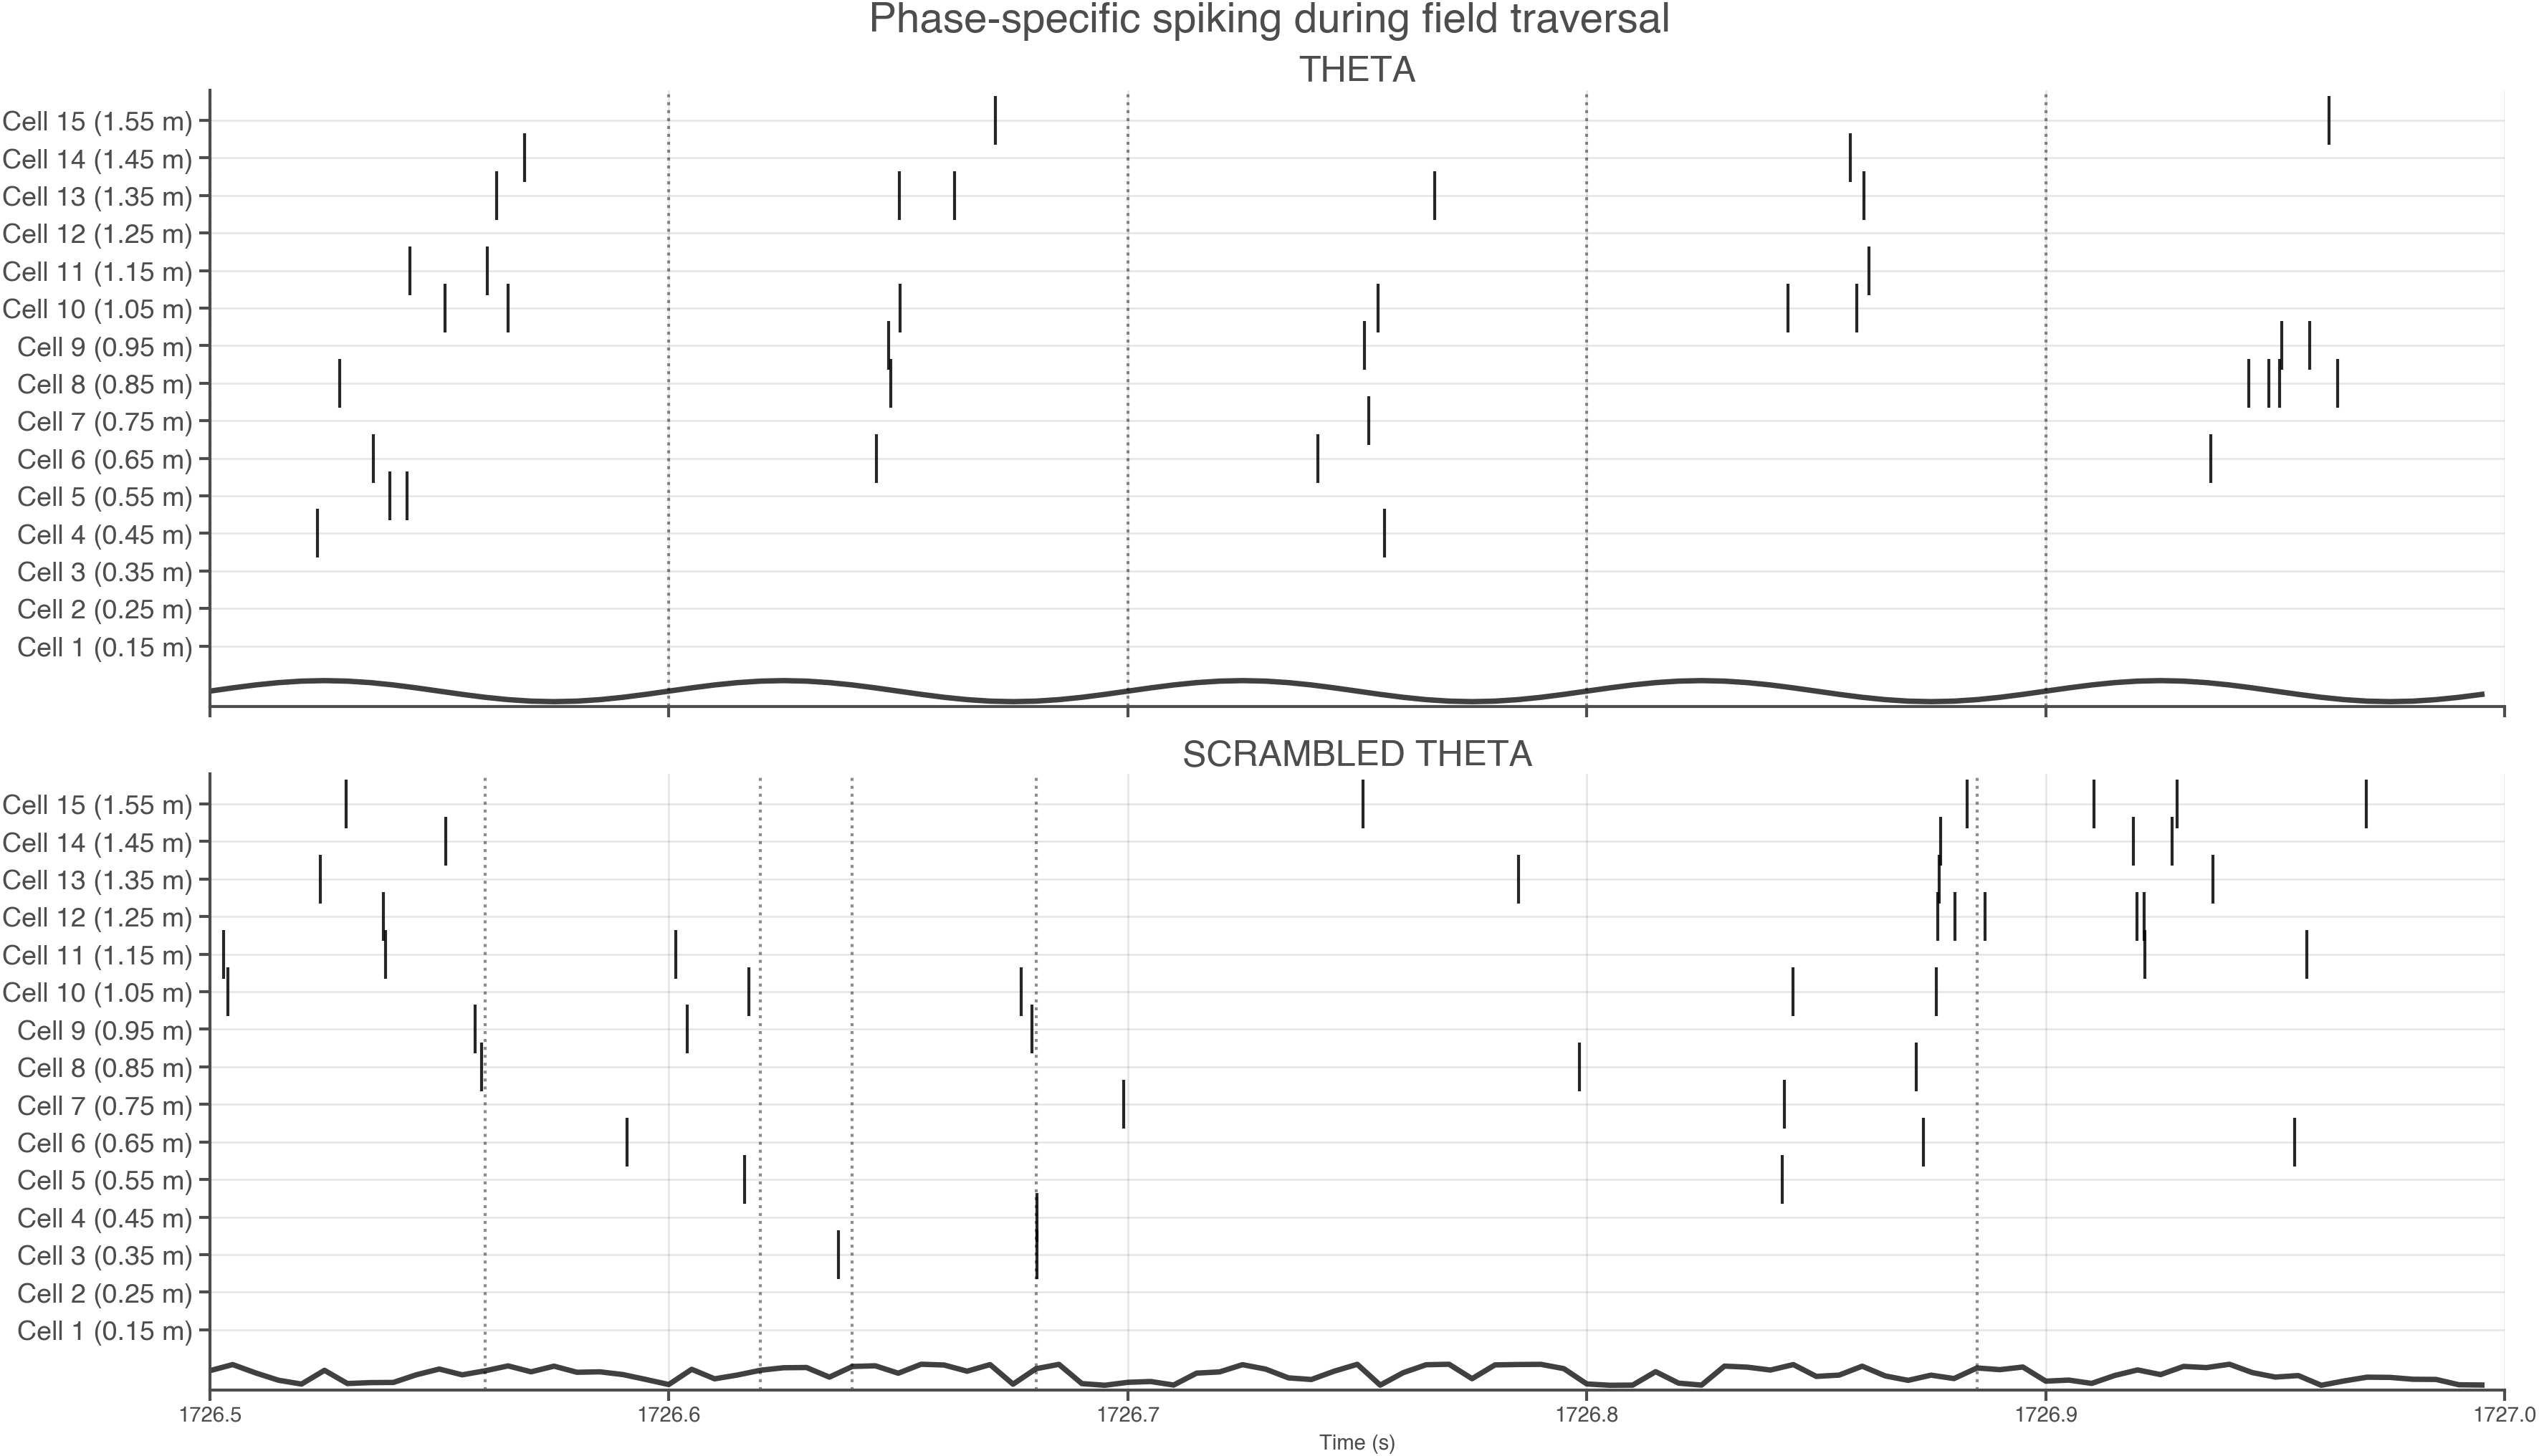

Saved: theta_phase_coding_raster.png


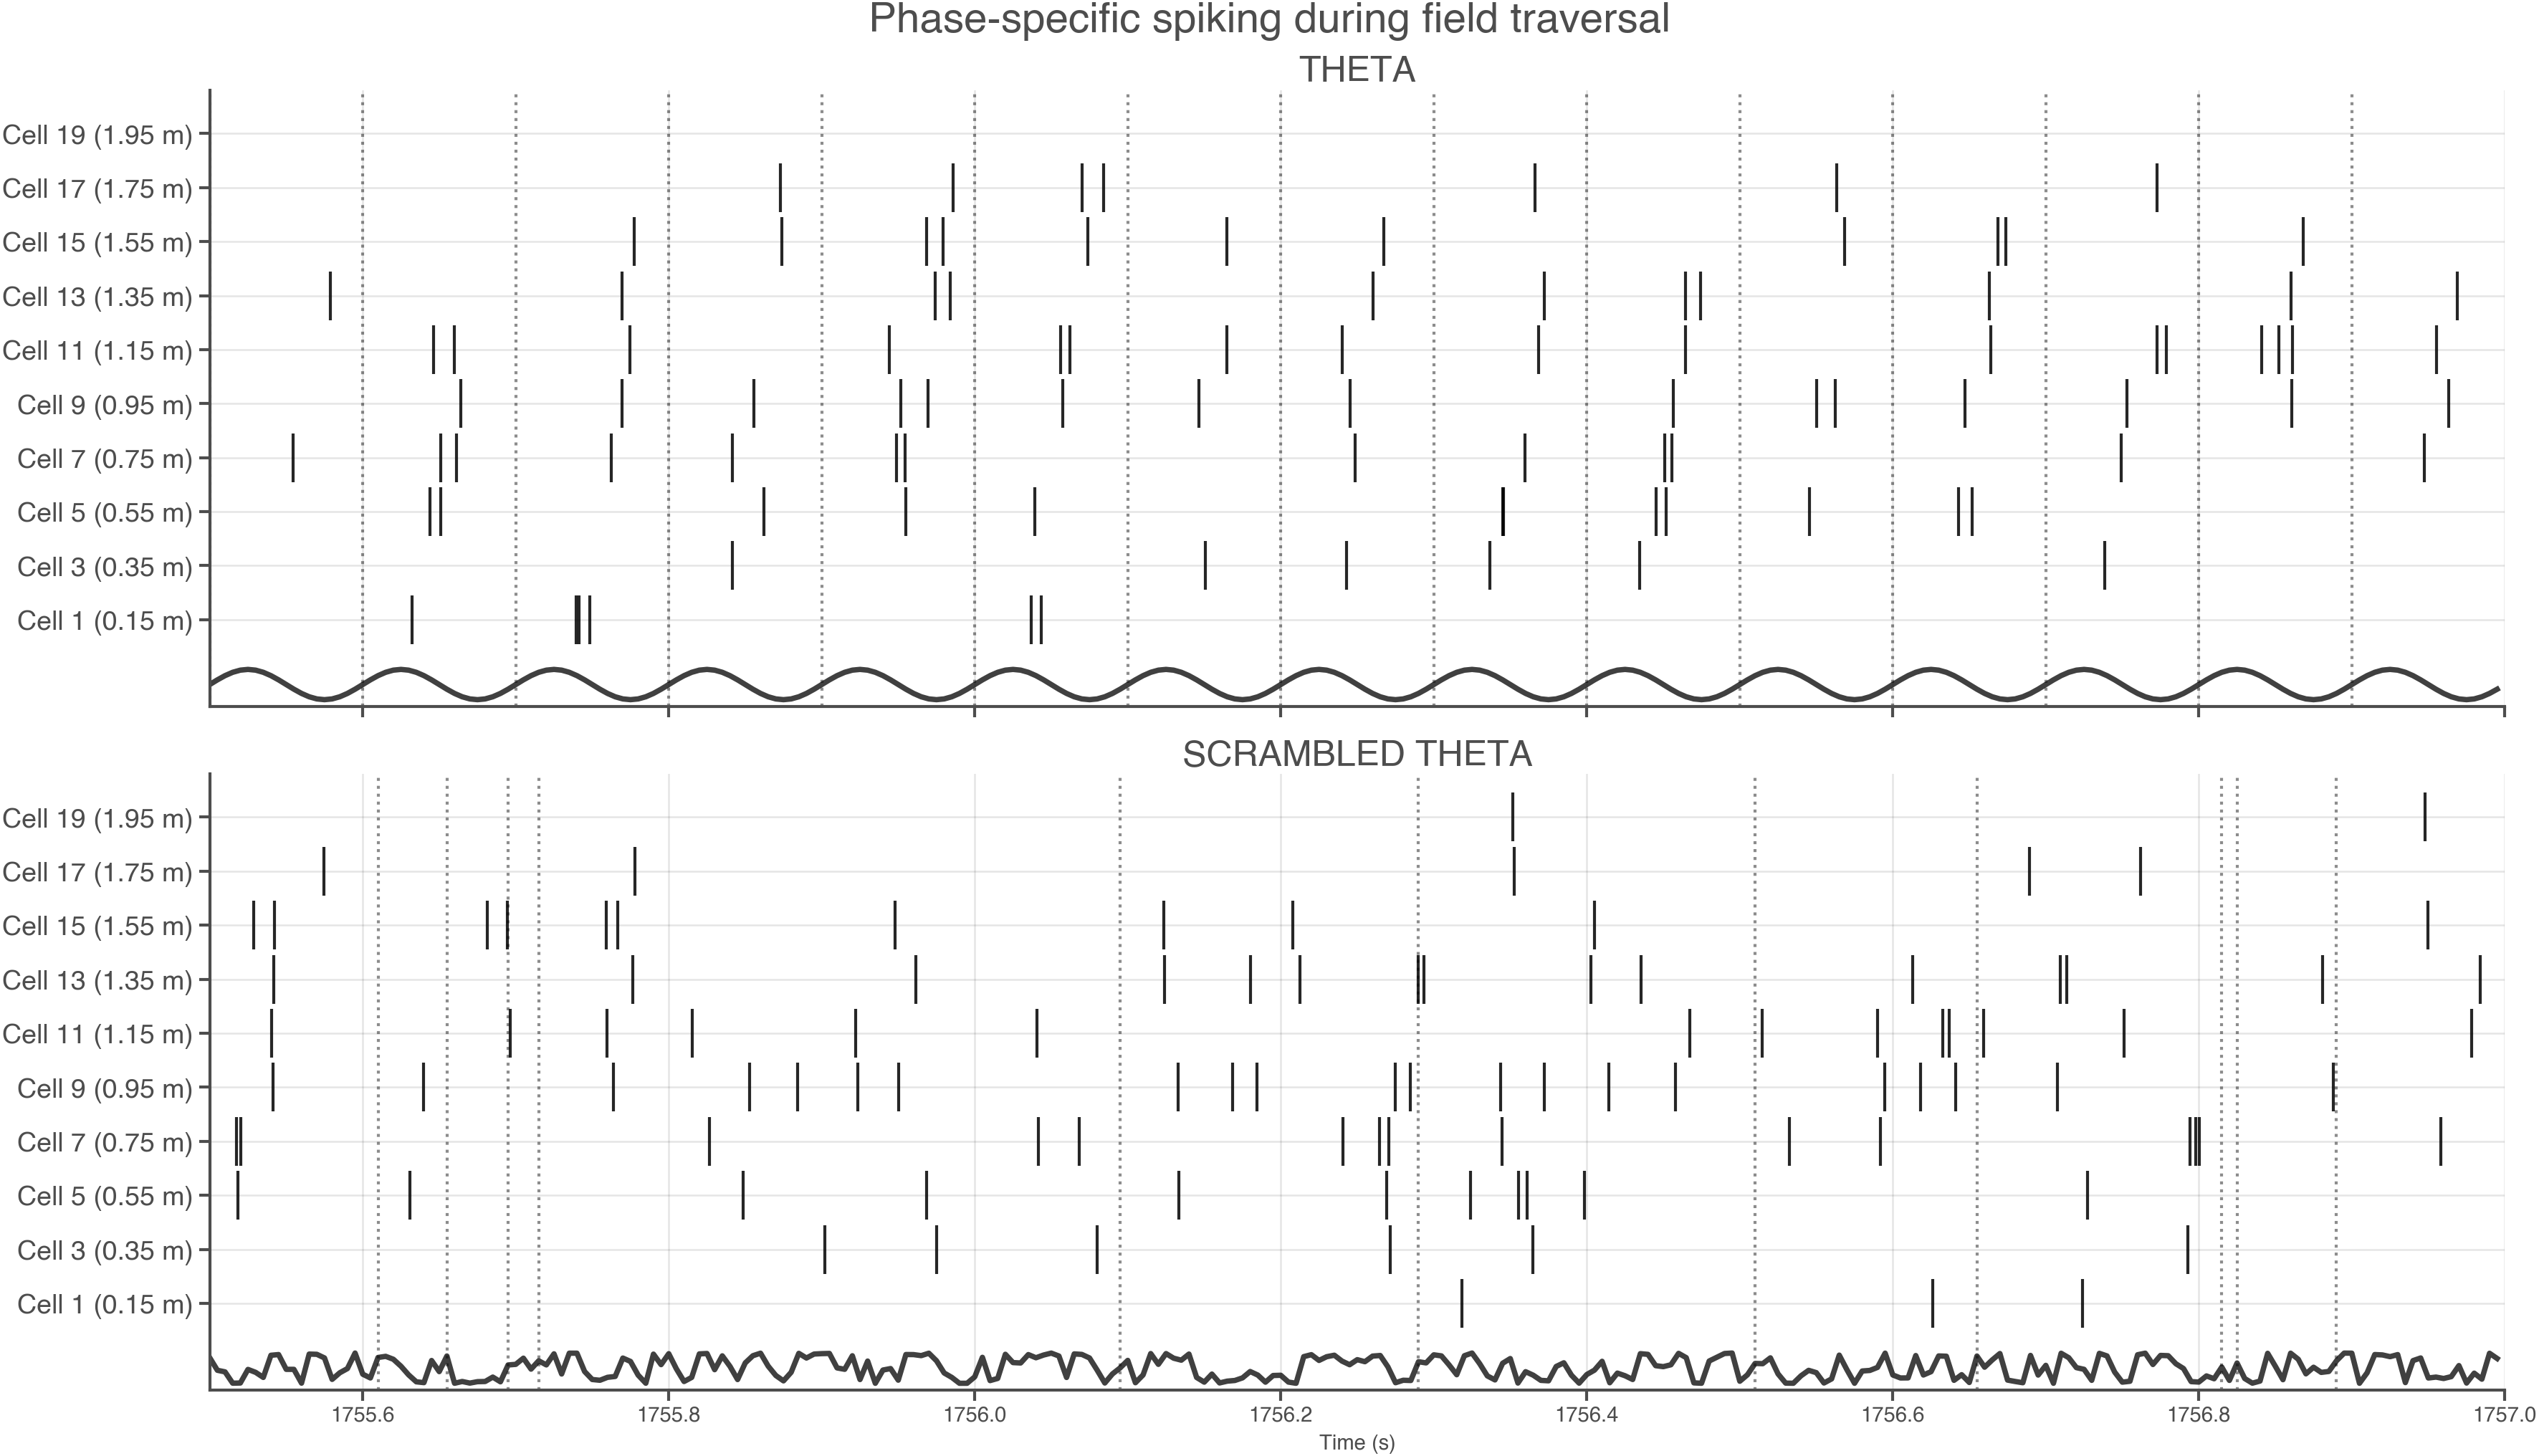

Saved: theta_phase_coding_raster.png


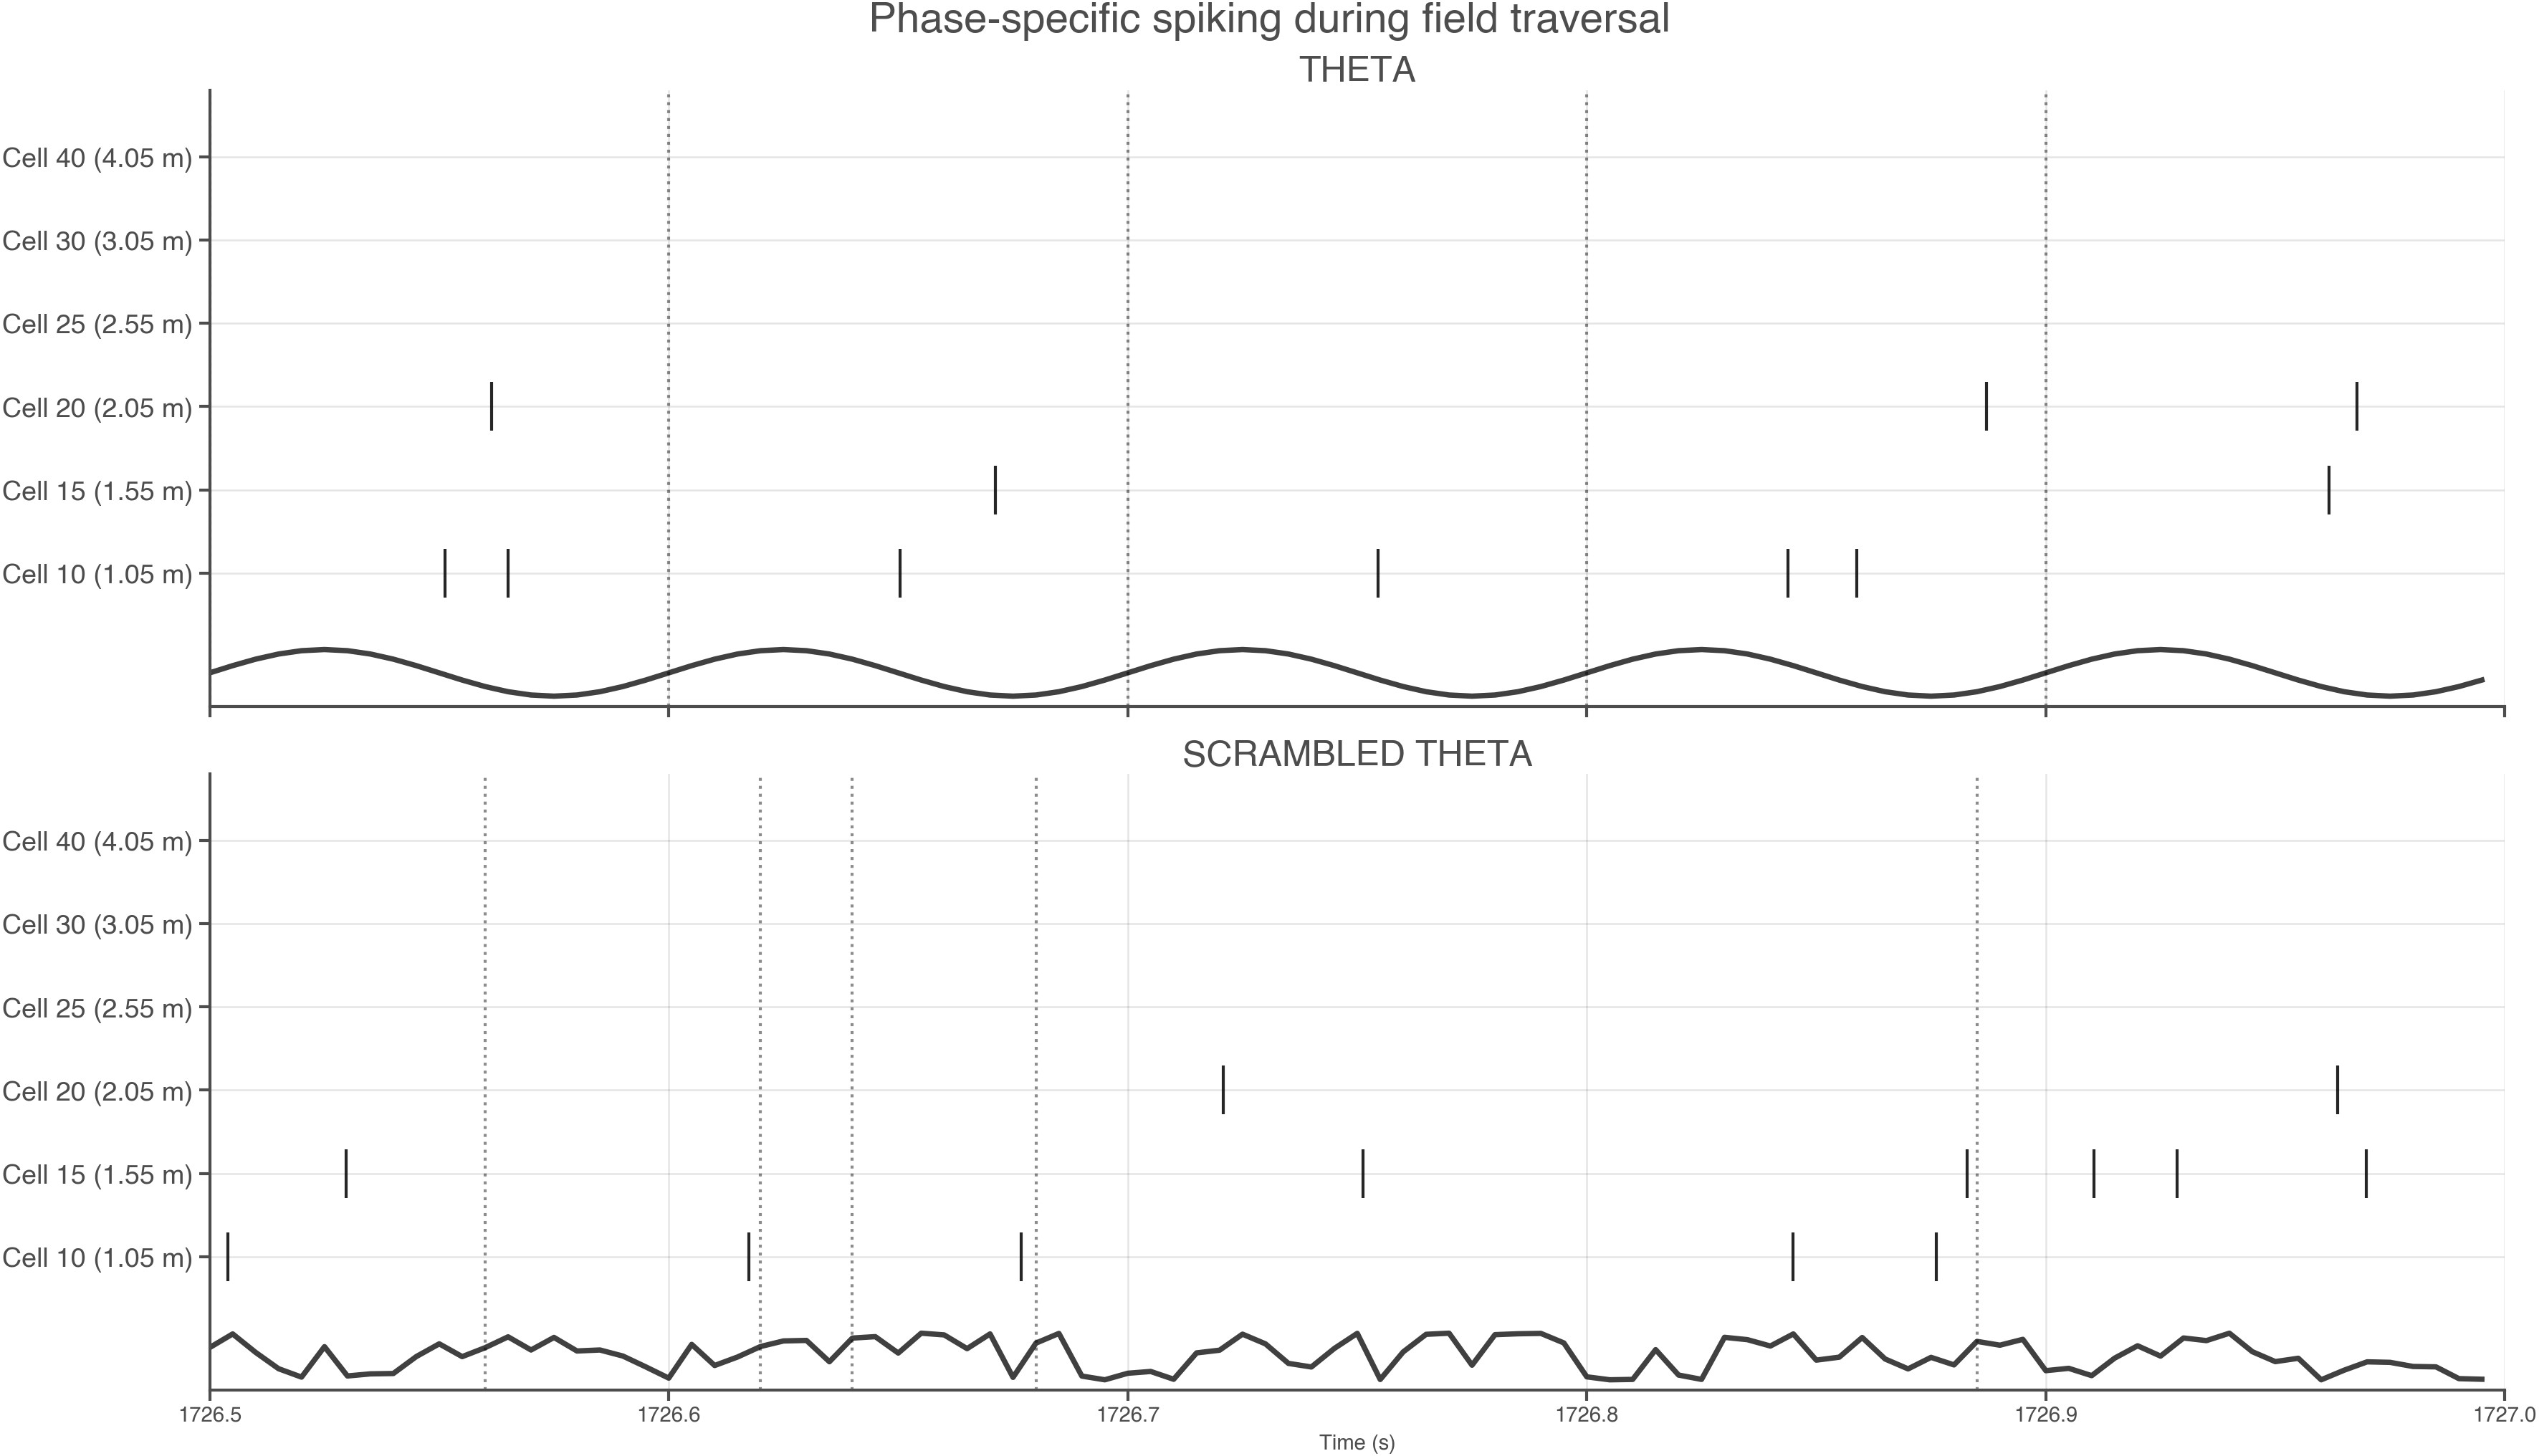

Saved: theta_phase_coding_raster.png


In [36]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def plot_theta_sequence_like_reference(
    agent,
    selected_cells=None,          # e.g. [15,20,25,30,35,40,45]
    t_start=6.0,
    t_end=7.2,
    save_path="theta_phase_coding_raster.png"
):
    plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

    # ---------- robust getters ----------
    def _get_t_history(a):
        if hasattr(a, "t_history"):
            return np.asarray(a.t_history, dtype=float).reshape(-1)
        return a.history["t"].to_numpy(dtype=float)

    def _get_phase(a, cond_key, t_hist):
        if cond_key == "theta":
            if hasattr(a, "thetaPhase_history"):
                ph = np.asarray(a.thetaPhase_history, dtype=float).reshape(-1)
                return np.mod(ph[:len(t_hist)], 2*np.pi)
            return np.mod(2*np.pi*a.thetaFreq*t_hist, 2*np.pi)

        # scrambled_theta
        if hasattr(a, "thetaPhase_scrambled_history"):
            ph = np.asarray(a.thetaPhase_scrambled_history, dtype=float).reshape(-1)
            return np.mod(ph[:len(t_hist)], 2*np.pi)

        # fallback
        return np.mod(2*np.pi*a.thetaFreq*t_hist, 2*np.pi)

    def _get_ca1(a, cond_key):
        d = a.spikedata_by_condition
        if cond_key in d:
            return d[cond_key]["CA1"]
        if cond_key == "scrambled_theta" and "scrambled" in d:
            return d["scrambled"]["CA1"]
        raise KeyError(f"Condition '{cond_key}' not found in spikedata_by_condition.")

    def _get_spikes(ca1, cell_id):
        # expected format: CA1[cell_id]['times']
        if isinstance(ca1, (list, tuple)):
            return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1)

        # alternate format: {'times':..., 'ids':...}
        if isinstance(ca1, dict) and ("times" in ca1) and ("ids" in ca1):
            st = np.asarray(ca1["times"], dtype=float).reshape(-1)
            sid = np.asarray(ca1["ids"], dtype=int).reshape(-1)
            return st[sid == cell_id]

        # dict keyed by cell_id
        if isinstance(ca1, dict) and (cell_id in ca1):
            return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1)

        raise TypeError("Unsupported CA1 spike format.")

    # ---------- arrays ----------
    t_hist = _get_t_history(agent)
    centres = np.asarray(agent.centres, dtype=float)

    if selected_cells is None:
        selected_cells = list(np.argsort(centres[:, 0])[20:27])
    else:
        selected_cells = list(selected_cells)

    y_labels = [f"Cell {cid} ({centres[cid,0]:.2f} m)" for cid in selected_cells]
    y_pos = np.arange(len(selected_cells), dtype=float)

    # ---------- figure ----------
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, facecolor="white")
    conditions = [("theta", "THETA"), ("scrambled_theta", "SCRAMBLED THETA")]

    for ax, (cond_key, title_txt) in zip(axes, conditions):
        ph = _get_phase(agent, cond_key, t_hist)
        n = min(len(t_hist), len(ph))
        tt, ph = t_hist[:n], ph[:n]
        m = (tt >= t_start) & (tt <= t_end)

        ca1 = _get_ca1(agent, cond_key)

        # spikes as vertical ticks
        for r, cid in enumerate(selected_cells):
            st = _get_spikes(ca1, int(cid))
            st = st[(st >= t_start) & (st <= t_end)]
            if st.size == 0:
                continue
            ax.scatter(
                st,
                np.full_like(st, y_pos[r], dtype=float),
                marker="|", s=260, c="black", alpha=0.85, linewidths=1.0
            )

        # top theta trace inside each panel
        y_theta = -1.2 + 0.28 * np.sin(ph[m])
        ax.plot(tt[m], y_theta, color="black", lw=1.8, alpha=0.75)

        # cycle boundaries
        wraps = np.where((ph[:-1] > 5.0) & (ph[1:] < 1.0))[0] + 1
        t_wrap = tt[wraps]
        t_wrap = t_wrap[(t_wrap >= t_start) & (t_wrap <= t_end)]
        for xc in t_wrap:
            ax.axvline(xc, color="black", ls=":", lw=1.0, alpha=0.45)

        ax.set_title(title_txt, fontsize=12, fontweight="bold")
        ax.set_facecolor("white")
        ax.grid(True, color="black", alpha=0.10, linewidth=0.6)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels, fontsize=9)
        ax.set_ylim(-1.6, len(selected_cells) - 0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlim(t_start, t_end)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Phase-specific spiking during field traversal", fontsize=14, fontweight="bold", y=0.98)
    fig.tight_layout()
    #fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {save_path}")

# run
plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10,11, 12, 13, 14, 15],
    t_start=1726.5,
    t_end=1727.0,
    save_path="theta_phase_coding_raster.png"
)

plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[1, 3, 5, 7, 9, 11, 13, 15,17,19],
    t_start=1755.5,
    t_end=1757.0,
    save_path="theta_phase_coding_raster.png"
)

plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[10, 15, 20, 25, 30, 40],
    t_start=1726.5,
    t_end=1727.0,
    save_path="theta_phase_coding_raster.png"
)

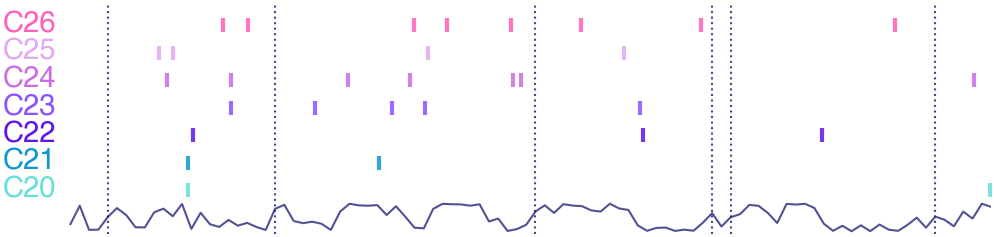

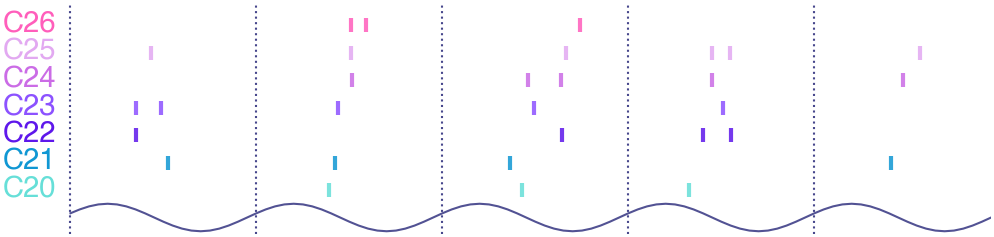

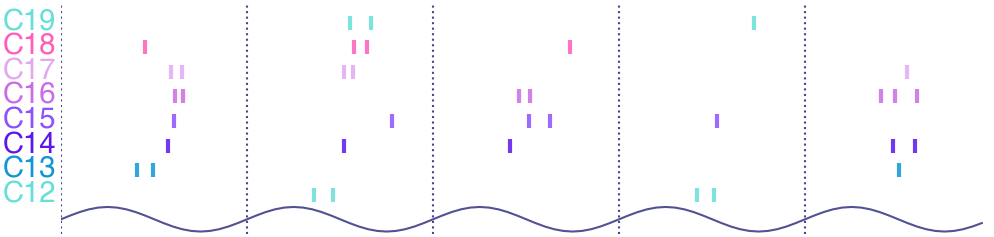

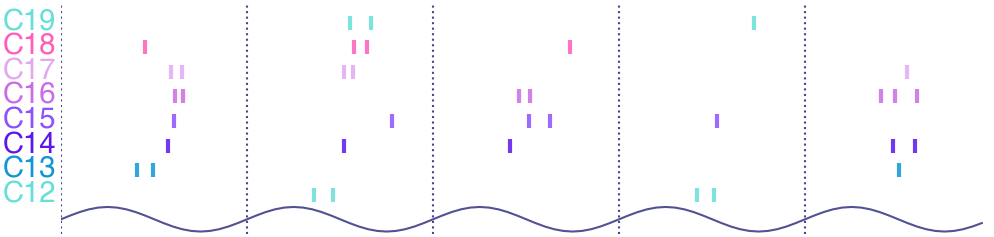

In [273]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def plot_theta_sequence_like_reference(
    agent,
    selected_cells=None,          # e.g. [15,20,25,30,35,40,45]
    t_start=6.0,
    t_end=7.2,
    condition_key="theta",           # "theta" or "scrambled_theta"
    save_path="theta_phase_coding_raster.png"
):
    plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

    # ---------- robust getters ----------
    def _get_t_history(a):
        if hasattr(a, "t_history"):
            return np.asarray(a.t_history, dtype=float).reshape(-1)
        return a.history["t"].to_numpy(dtype=float)

    def _get_phase(a, cond_key, t_hist):
        if cond_key == "theta": 
            if hasattr(a, "thetaPhase_history"):
                ph = np.asarray(a.thetaPhase_history, dtype=float).reshape(-1)
                return np.mod(ph[:len(t_hist)], 2*np.pi)
            return np.mod(2*np.pi*a.thetaFreq*t_hist, 2*np.pi)

        # scrambled_theta
        if hasattr(a, "thetaPhase_scrambled_history"):
            ph = np.asarray(a.thetaPhase_scrambled_history, dtype=float).reshape(-1)
            return np.mod(ph[:len(t_hist)], 2*np.pi)

        # fallback
        return np.mod(2*np.pi*a.thetaFreq*t_hist, 2*np.pi)

    def _get_ca1(a, cond_key):
        d = a.spikedata_by_condition
        if cond_key in d:
            return d[cond_key]["CA1"]
        if cond_key == "scrambled_theta" and "scrambled" in d:
            return d["scrambled"]["CA1"]
        raise KeyError(f"Condition '{cond_key}' not found in spikedata_by_condition.")

    def _get_spikes(ca1, cell_id):
        # expected format: CA1[cell_id]['times']
        if isinstance(ca1, (list, tuple)):
            return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1) # return spike times for this cell

        # alternate format: {'times':..., 'ids':...}
        if isinstance(ca1, dict) and ("times" in ca1) and ("ids" in ca1):
            st = np.asarray(ca1["times"], dtype=float).reshape(-1)
            sid = np.asarray(ca1["ids"], dtype=int).reshape(-1)
            return st[sid == cell_id] # return spike times for this cell by masking with cell_id

        # dict keyed by cell_id
        if isinstance(ca1, dict) and (cell_id in ca1):
            return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1) # return spike times for this cell

        raise TypeError("Unsupported CA1 spike format.")

    # ---------- arrays ----------
    t_hist = _get_t_history(agent)
    centres = np.asarray(agent.centres, dtype=float)

    if selected_cells is None:
        selected_cells = list(np.argsort(centres[:, 0])[20:27])
    else:
        selected_cells = list(selected_cells)

    y_labels = [f"C{cid}" for cid in selected_cells]
    y_pos = np.arange(len(selected_cells), dtype=float)
    colors = ['#66dfd8', "#1097d3", '#5e17eb', '#8c52ff', '#cb6ce6', '#e2a9f1', '#ff5ebb', '#66dfd8', "#1097d3", '#5e17eb', '#8c52ff', '#cb6ce6', '#e2a9f1', '#ff5ebb'] # repeat colors if more than 8 cells

    # ---------- figure ----------
    fig, ax = plt.subplots(figsize=(4, 1.0), sharex=True)
    if condition_key == "theta":
        conditions = [("theta", "THETA")]
    elif condition_key == "scrambled":
        conditions = [("scrambled_theta", "SCRAMBLED THETA")]
    else:        raise ValueError(f"Unknown condition_key: {condition_key}")

    #conditions = [("theta", "THETA"), ("scrambled_theta", "SCRAMBLED THETA")]

    #for ax, (cond_key, title_txt) in zip(axes, conditions):
    for cond_key, title_txt in conditions:
        ph = _get_phase(agent, cond_key, t_hist)
        # couble check if t_hist and ph are of the same length 
        if len(t_hist) != len(ph):
            print(f"Warning: t_hist and phase history have different lengths ({len(t_hist)} vs {len(ph)}). Aligning to the shorter one.")
        n = min(len(t_hist), len(ph)) #
        tt, ph = t_hist[:n], ph[:n] # align lengths safely
        m = (tt >= t_start) & (tt <= t_end) # mask for the time window we want to plot

        ca1 = _get_ca1(agent, cond_key) # get CA1 spike data for this condition

        # spikes as vertical ticks in colour for each cell
        for r, cid in enumerate(selected_cells): # loop over selected cells and plot their spikes
            st = _get_spikes(ca1, int(cid)) # get spike times for this cell
            st = st[(st >= t_start) & (st <= t_end)] # further mask to select spikes within the time window 
            if st.size == 0: # skip if there are no spikes in time window
                continue
            ax.scatter(
                st,
                np.full_like(st, y_pos[r], dtype=float), #np.full_like creates an array of the same shape as st filled with the y position for this cell, so all spikes of this cell will be plotted at the same y level
                marker="|", c=colors[r], s=10, alpha=0.85, linewidths=1.0
            )

        # top theta trace inside each panel
        y_theta = -1.0 + 0.5 * np.sin(ph[m]) # first value is y coordinate of theta wave, 2nd value is amplitude of wave
        ax.plot(tt[m], y_theta, color="midnightblue", alpha=0.75)

        # cycle boundaries
        # set boundaries to be at peak of theta phase, not! at half cycles points
        #wraps = np.where(())
        #if condition_key == "theta":
        wraps = np.where((ph[:-1] > 5.0) & (ph[1:] < 1.0))[0] + 1 # for lines at peaks: ((ph[:-1] < 1.28) & (ph[1:] > 1.28)) 
        t_wrap = tt[wraps]
        t_wrap = t_wrap[(t_wrap >= t_start) & (t_wrap <= t_end)]
        for xc in t_wrap:
            ax.axvline(xc, color="midnightblue", ls=":", alpha=0.8)

        #ax.set_title(title_txt, fontweight="bold")
        #ax.set_facecolor("white")
        ax.grid(True, color="black", alpha=0.10)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels)
        ax.set_ylim(-1.6, len(selected_cells) - 0.2)
        #ax.spines["top"].set_visible(False)
        #ax.spines["right"].set_visible(False)
        #ax.spines['bottom'].set_visible(False)
        ax.set_axis_off()
        # plot cell labels to the left of the y-axis
        for r, label in enumerate(y_labels):
            ax.text(t_start - 0.005*(t_end-t_start), y_pos[r], label, ha='right', va='center', color=colors[r])


    ax.set_xlim(t_start, t_end)
    ax.set_xlabel("Time (s)")
    #fig.suptitle("Phase-specific spiking during field traversal", fontweight="bold", y=0.98)
    #fig.tight_layout()
    #fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    return fig
    #print(f"Saved: {save_path}")

# run
fig1 = plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[20, 21, 22, 23, 24, 25, 26],
    t_start=109.1,
    t_end=109.6,
    condition_key="scrambled",
    save_path="theta_phase_coding_raster.png"
)
# save fig1 with transparent background
#fig1.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/SpikeRasterScrambled500ms.pdf", transparent = True)

fig2 = plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[20, 21, 22, 23, 24, 25, 26],
    t_start=109.1, # original values 1755.5, 1756.0
    t_end=109.6,
    condition_key="theta",
    save_path="theta_phase_coding_raster.png"
)

# save fig2 with transparent background
#fig2.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/SpikeRasterIntact500ms.pdf", transparent = True)

plot_theta_sequence_like_reference(
    agent_p,
    selected_cells=[12, 13, 14, 15, 16, 17, 18, 19],
    t_start=1729.5, # original values 1726.5, 1727.0
    t_end=1730.0,
    condition_key = "theta",
    save_path="theta_phase_coding_raster.png"
)

In [147]:
thetaPhaseStart = 10*(0.0%(1/10))*2*np.pi
print(thetaPhaseStart)

0.0


### Issue
in the model theta is inialised as a sine wave which has phase 0 at $t=0$, therefore the first peak of the wave is at $1/2 \pi$, and the through is at $1.5 \pi$. Hence the midpoint of the cycle is not at the through as it is biologically, but at the midpoint between peak and through. 
To make this bilogically plausible, at least for the plotting, the oscillations should be initiallised as a cosine wave, not as a sine wave, so that the peak is at $t=0$ and the through at $\pi$

In [275]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def _get_pos(a, t_hist):
    """Extract x, y position history from agent, handling (x,y) tuple columns."""
    if hasattr(a, 'pos_history'):
        return np.asarray(a.pos_history, dtype=float)[:len(t_hist)]
    
    # pos column contains (x, y) tuples/arrays per row — stack them
    pos_series = a.history['pos'].iloc[:len(t_hist)]
    return np.stack(pos_series.values).astype(float)  # shape (n_timepoints, 2)

def _get_positions(a, t_hist):
    """Extract x, y position history aligned to t_hist."""
    if hasattr(a, 'pos_history'):
        pos = np.asarray(a.pos_history, dtype=float)
    elif 'x' in a.history.columns:
        pos = a.history[['x', 'y']].to_numpy(dtype=float)
    else:
        raise AttributeError("Cannot find position history on agent.")
    return pos[:len(t_hist)]   # align length to t_hist

def _get_t_history(a):
    if hasattr(a, "t_history"):
        return np.asarray(a.t_history, dtype=float).reshape(-1)
    return a.history["t"].to_numpy(dtype=float)

def _get_ca1(a, cond_key):
    d = a.spikedata_by_condition
    if cond_key in d:
        return d[cond_key]["CA1"]
    if cond_key == "scrambled_theta" and "scrambled" in d:
        return d["scrambled"]["CA1"]
    raise KeyError(f"Condition '{cond_key}' not found in spikedata_by_condition.")

def _get_spikes(ca1, cell_id):
    # expected format: CA1[cell_id]['times']
    if isinstance(ca1, (list, tuple)):
        return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1) # return spike times for this cell

    # alternate format: {'times':..., 'ids':...}
    if isinstance(ca1, dict) and ("times" in ca1) and ("ids" in ca1):
        st = np.asarray(ca1["times"], dtype=float).reshape(-1)
        sid = np.asarray(ca1["ids"], dtype=int).reshape(-1)
        return st[sid == cell_id] # return spike times for this cell by masking with cell_id

    # dict keyed by cell_id
    if isinstance(ca1, dict) and (cell_id in ca1):
        return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1) # return spike times for this cell

    raise TypeError("Unsupported CA1 spike format.")

cond_key  = 'theta'            # or 'scrambled_theta'
neuron_id = 5
agent      = agent_p

t_hist    = _get_t_history(agent)
positions = _get_pos(agent, t_hist)
ca1       = _get_ca1(agent, cond_key)
spikes    = _get_spikes(ca1, neuron_id)   # 1D array of spike times

def plot_place_field(fig, ax, spike_times, positions, times, neuron_id,
                     bin_size=2.5, sigma=1.5):
    """
    Parameters
    ----------
    fig, ax       : from plotMazeStructure()
    spike_times   : dict {neuron_id: array of spike times}  OR  2D array (n_spikes, 2) with [neuron_id, time]
    positions     : 2D array (n_timepoints, 2) with [x, y] agent positions
    times         : 1D array of timepoints matching positions
    neuron_id     : which neuron to plot (e.g. 5)
    bin_size      : spatial bin size in whatever units your maze uses
    sigma         : gaussian smoothing (in bins); increase for smoother field
    """

    # ── 1. Extract spike times for the chosen neuron ──────────────────────────
    if isinstance(spike_times, dict):
        neuron_spikes = np.asarray(spike_times[neuron_id])
    else:
        mask = spike_times[:, 0] == neuron_id
        neuron_spikes = spike_times[mask, 1]

    # ── 2. Find agent position at each spike time ─────────────────────────────
    spike_positions = np.array([
        positions[np.argmin(np.abs(times - t))]
        for t in neuron_spikes
    ])

    # ── 3. Define spatial bins from maze extent ───────────────────────────────
    x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
    y_min, y_max = positions[:, 1].min(), positions[:, 1].max()

    x_bins = np.arange(x_min, x_max + bin_size, bin_size)
    y_bins = np.arange(y_min, y_max + bin_size, bin_size)

    # ── 4. Occupancy map (time spent in each bin) ─────────────────────────────
    occupancy, _, _ = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=[x_bins, y_bins]
    )
    dt = np.mean(np.diff(times))          # seconds per sample
    occupancy_sec = occupancy * dt        # convert counts → seconds

    # ── 5. Spike count map ────────────────────────────────────────────────────
    spike_map, _, _ = np.histogram2d(
        spike_positions[:, 0], spike_positions[:, 1],
        bins=[x_bins, y_bins]
    )

    # ── 6. Firing rate map = spikes / occupancy; mask unvisited bins ──────────
    min_occupancy = 0.1                   # seconds; ignore barely-visited bins
    rate_map = np.full(spike_map.shape, np.nan)
    visited = occupancy_sec > min_occupancy
    rate_map[visited] = spike_map[visited] / occupancy_sec[visited]

    # ── 7. Gaussian smooth (ignore NaNs) ─────────────────────────────────────
    filled = np.where(np.isnan(rate_map), 0, rate_map)
    smoothed = gaussian_filter(filled, sigma=sigma)
    smoothed[~visited] = np.nan           # reapply NaN mask after smoothing

    # ── 8. Plot on existing maze figure ───────────────────────────────────────
    extent = [x_min, x_max, y_min, y_max]
    im = ax.imshow(
        smoothed.T,                       # transpose: imshow expects (y, x)
        origin='lower',
        extent=extent,
        cmap='hot',
        alpha=0.75,                       # lets maze structure show through
        aspect='auto',
        interpolation='bilinear'
    )

    # Overlay individual spike locations as dots
    ax.scatter(spike_positions[:, 0], spike_positions[:, 1],
               s=4, c='white', alpha=0.4, zorder=3)

    cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Firing rate (Hz)', fontsize=8)

    ax.set_title(f'Neuron {neuron_id} — place field\n'
                 f'({len(neuron_spikes)} spikes)', fontsize=9)

    return smoothed, x_bins, y_bins

In [277]:
cond_key  = 'theta'
neuron_id = 5

t_hist    = _get_t_history(agent)
positions = _get_pos(agent, t_hist)
ca1       = _get_ca1(agent, cond_key)
spikes    = _get_spikes(ca1, neuron_id)

print(f"t_hist:    {t_hist.shape},    range [{t_hist.min():.2f}, {t_hist.max():.2f}] s")
print(f"positions: {positions.shape}, range x={positions[:,0].min():.2f}–{positions[:,0].max():.2f}, y={positions[:,1].min():.2f}–{positions[:,1].max():.2f}")
print(f"spikes:    {spikes.shape},    range [{spikes.min():.2f}, {spikes.max():.2f}] s")

t_hist:    (359999,),    range [0.01, 1800.00] s
positions: (359999, 2), range x=0.00–5.00, y=0.10–0.10
spikes:    (4245,),    range [0.08, 1790.52] s


In [ ]:
fig, ax = plotter.plotMazeStructure()

rate_map, x_bins, y_bins = plot_place_field(
    fig, ax,
    spike_times=spike_times,   # your spike data
    positions=positions,        # shape (n_timepoints, 2)
    times=times,                # shape (n_timepoints,)
    neuron_id=5,
    bin_size=2.5,               # tune to your maze scale
    sigma=1.5                   # tune smoothing
)

plt.show()